In [76]:
import os
import numpy as np
import pandas as pd
import umap
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import axes3d
from scipy.io import loadmat
from sklearn.decomposition import PCA
import statsmodels.api as sm
import scipy.stats as stats

data_dir = '../data'
output_dir = '../outputs'

colors = mcolors.CSS4_COLORS
by_hsv = sorted((tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(color))), name)
                for name, color in colors.items())
color_names = [name for hsv, name in by_hsv]

In [77]:
# load 1854*49 embeddings
embedding_49 = np.loadtxt(os.path.join(data_dir, 'spose_embedding_49d_sorted.txt'))
embedding_49.shape

(1854, 49)

In [78]:
# load 1854*66 embeddings
embedding_66 = np.loadtxt(os.path.join(data_dir, 'spose_embedding_66d_sorted.txt'))
embedding_66.shape

(1854, 66)

In [79]:
### Other supporting data
# Concept and category mapping
cat_mapping = pd.read_csv(os.path.join(data_dir, 'THINGS_Table.csv'))
cat_concept_mem = cat_mapping[['cr', 'smallcat', 'bigcat']].groupby('smallcat').mean()
cat_concept_mem['bigcat'] = cat_concept_mem['bigcat'].astype(int).replace(0, 99)

# Category names
cat = loadmat(os.path.join(data_dir,'categories.mat'))
cat_names = [item[0] for item in cat['categories'][0]]
cat_names.append('na')
cat_names = pd.DataFrame(cat_names, columns=['cat_name']).reset_index()
cat_names['index'] = cat_names['index']+1
cat_names.iloc[27] = [99, np.nan]
cat_concept_mem = cat_concept_mem.merge(cat_names, how='left', left_on='bigcat', right_on='index').drop(columns=['index'])
cat_concept_mem

,cr,bigcat,cat_name
0,0.779739,1,animal
1,0.798485,13,home decor
2,0.752845,18,musical instrument
3,0.761851,99,NaN
4,0.794466,9,electronic device
...,...,...,...
1849,0.722655,99,NaN
1850,0.843158,10,food
1851,0.800163,1,animal
1852,0.797468,99,NaN


In [80]:
# Construct RDMs
temp_49 = abs(np.corrcoef(embedding_49, rowvar=False))
rdm_49 = 1 - np.abs(np.corrcoef(embedding_49, rowvar=False))
eps = 1e-15
rdm_49[np.abs(rdm_49) < eps] = 0.00000000e+00

temp_66 = abs(np.corrcoef(embedding_66, rowvar=False))
rdm_66 = 1 - np.abs(np.corrcoef(embedding_66, rowvar=False))
rdm_66[np.abs(rdm_66) < eps] = 0.00000000e+00

In [81]:
### Dimensionality reduction (UMAP) using Albatross-tested model embeddings
def draw_umap(dim, metric, data, pca=False, pca_dim=3, color_coded=False):
    mapper = None
    if metric == 'hyperbolic':
        mapper = umap.UMAP(n_components=dim, output_metric='hyperboloid', random_state=42).fit(data)
    else:
        mapper = umap.UMAP(n_components=dim, metric=metric, random_state=42).fit(data)
    # feature_49 = eu_mapper.embedding_[:, :]
    # z_embedding_49 = (embedding_49.T/np.sqrt((embedding_49**2).sum(axis=1))).T
    # concept_49 = z_embedding_49@feature_49
    concept = mapper.embedding_
    
    if pca:
        concept = PCA(n_components=pca_dim).fit_transform(concept)
        
    concept = pd.DataFrame(concept)
    
    if color_coded:
        concept = concept.merge(cat_concept_mem['cat_name'], how='left', left_index=True, right_index=True)
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(projection='3d')

    # Set background color of the 3D plot area
    ax.set_facecolor('white') 

    # Set grid color to grey
    ax.xaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')
    ax.yaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')
    ax.zaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')

    ax.w_xaxis.line.set_color("grey")
    ax.w_yaxis.line.set_color("grey")
    ax.w_zaxis.line.set_color("grey")

    # Set background color to white
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')

    # ax.scatter(feature_49.T[0], feature_49.T[1], feature_49.T[2], color='red')
    # ax.scatter(concept_49.T[0], concept_49.T[1], concept_49.T[2])
    # ax.scatter(eu_mapper.embedding_.T[0], eu_mapper.embedding_.T[1], eu_mapper.embedding_.T[2])

    if color_coded:
        groups = concept.groupby("cat_name")
        i = 3
        for name, group in groups:
            ax.scatter(group[0], group[1], group[2], label=name, alpha=0.7, color=color_names[i])
            i = i+6
        fig.legend(loc='lower center', ncol=3, facecolor='white',fontsize=12, markerscale=1)
    else:
        ax.scatter(concept[0], concept[1], concept[2])
        
    ax.set_xlabel('$X$', fontsize=15)
    ax.set_ylabel('$Y$', fontsize=15)
    ax.set_zlabel('$Z$', fontsize=15)

    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    plt.tight_layout(pad=5)


/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


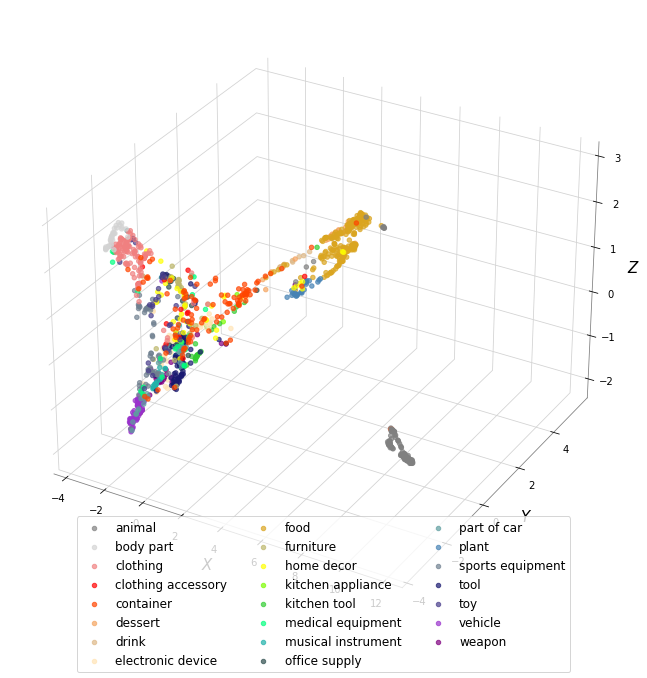

In [82]:
# 49d
### 16d Eu space
draw_umap(dim=16, metric='euclidean', data=embedding_49, pca=True, pca_dim=3, color_coded=True)

/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


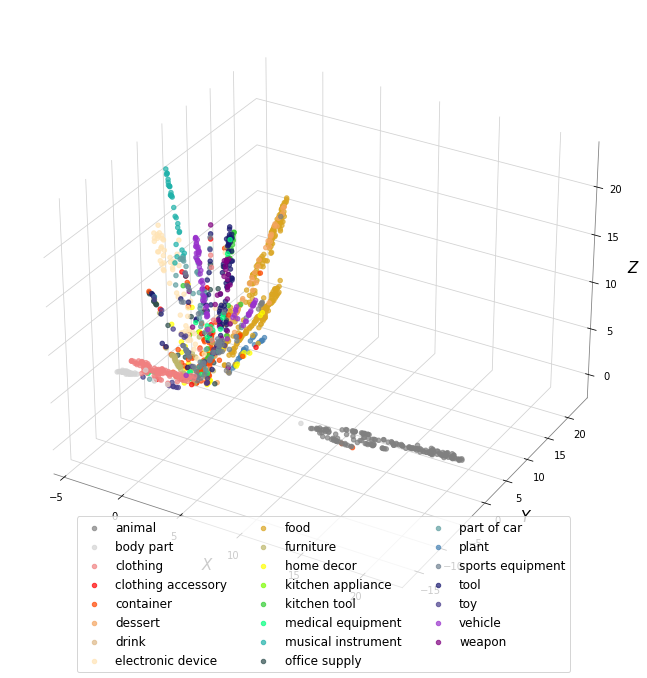

In [83]:
# 49d
### 3d Hyperbolic space
draw_umap(dim=3, metric='hyperbolic', data=embedding_49, pca=False, pca_dim=3, color_coded=True)


/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


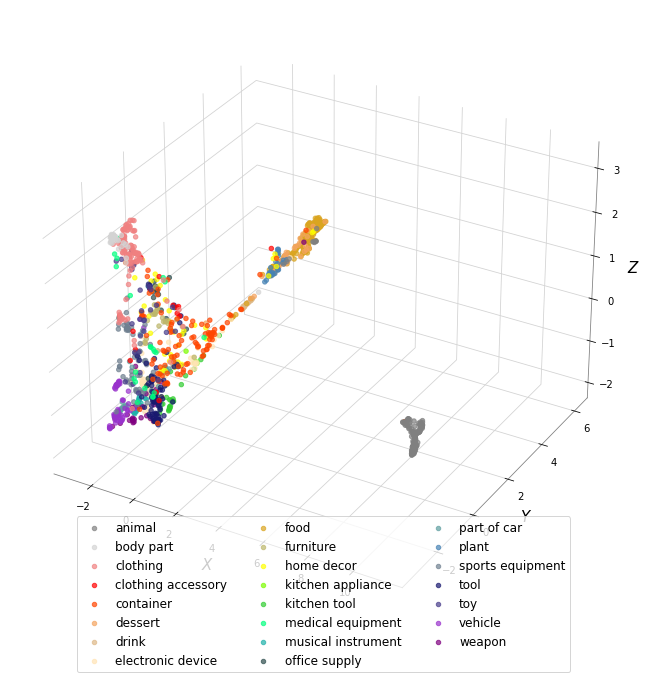

In [84]:
# 66d
### 16d Eu space
draw_umap(dim=16, metric='euclidean', data=embedding_66, pca=True, pca_dim=3, color_coded=True)


/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


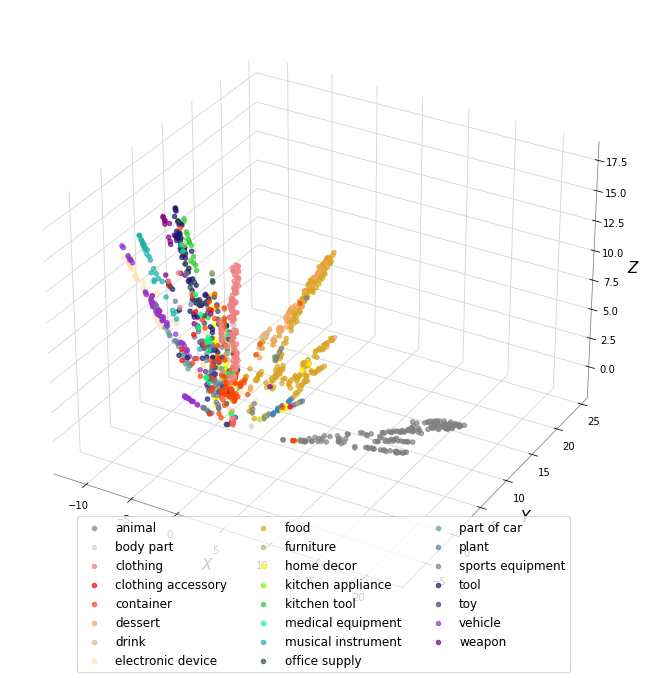

In [85]:
# 66d
### 3d hbp space
draw_umap(dim=3, metric='hyperbolic', data=embedding_66, pca=False, pca_dim=3, color_coded=True)

In [86]:
### Dimensionality reduction (UMAP) using RDM
def draw_umap_rdm(dim, metric, data, rdm, pca=False, pca_dim=3, color_coded=False, filename=None):
    mapper = None
    if metric == 'hyperbolic':
        mapper = umap.UMAP(n_components=dim, metric='precomputed', output_metric='hyperboloid', random_state=42).fit(rdm)
    else:
        mapper = umap.UMAP(n_components=dim, metric='precomputed', random_state=42).fit(rdm)
    
    feature = mapper.embedding_[:, :] 
    if pca:
        feature = PCA(n_components=pca_dim).fit_transform(feature)
    
    z_embedding = (data.T/np.sqrt((data**2).sum(axis=1))).T
    concept = z_embedding@feature
    concept = pd.DataFrame(concept)
    
    if color_coded:
        concept = concept.merge(cat_concept_mem['cat_name'], how='left', left_index=True, right_index=True)
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(projection='3d')

    # Set background color of the 3D plot area
    ax.set_facecolor('white') 

    # Set grid color to grey
    ax.xaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')
    ax.yaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')
    ax.zaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')

    ax.w_xaxis.line.set_color("grey")
    ax.w_yaxis.line.set_color("grey")
    ax.w_zaxis.line.set_color("grey")

    # Set background color to white
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')

    # ax.scatter(feature.T[0], feature.T[1], feature.T[2], color='black')
    # ax.scatter(concept_49.T[0], concept_49.T[1], concept_49.T[2])
    # ax.scatter(eu_mapper.embedding_.T[0], eu_mapper.embedding_.T[1], eu_mapper.embedding_.T[2])

    if color_coded:
        groups = concept.groupby("cat_name")
        i = 3
        for name, group in groups:
            ax.scatter(group[0], group[1], group[2], label=name, alpha=0.5, color=color_names[i])
            i = i+6
        fig.legend(loc='lower center', ncol=3, facecolor='white',fontsize=12, markerscale=1)
    else:
        ax.scatter(concept[0], concept[1], concept[2])
        
    ax.set_xlabel('$X$', fontsize=15)
    ax.set_ylabel('$Y$', fontsize=15)
    ax.set_zlabel('$Z$', fontsize=15)

    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    plt.tight_layout(pad=5)

    if filename:
        plt.savefig(f'../outputs/{filename}.pdf')


/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


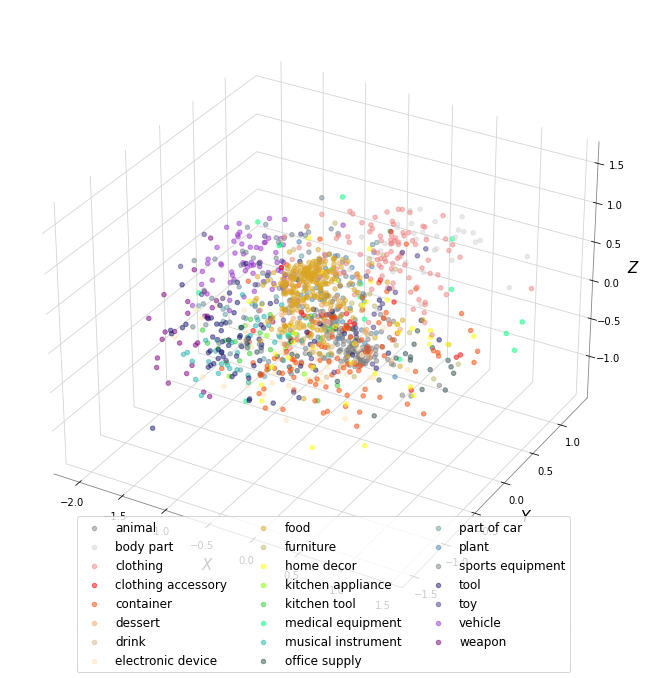

In [87]:
# 49d
### 16d eu space
draw_umap_rdm(dim=16, metric='euclidean', data=embedding_49, rdm=rdm_49, pca=True, pca_dim=3, color_coded=True, filename='eu_category_66')

/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


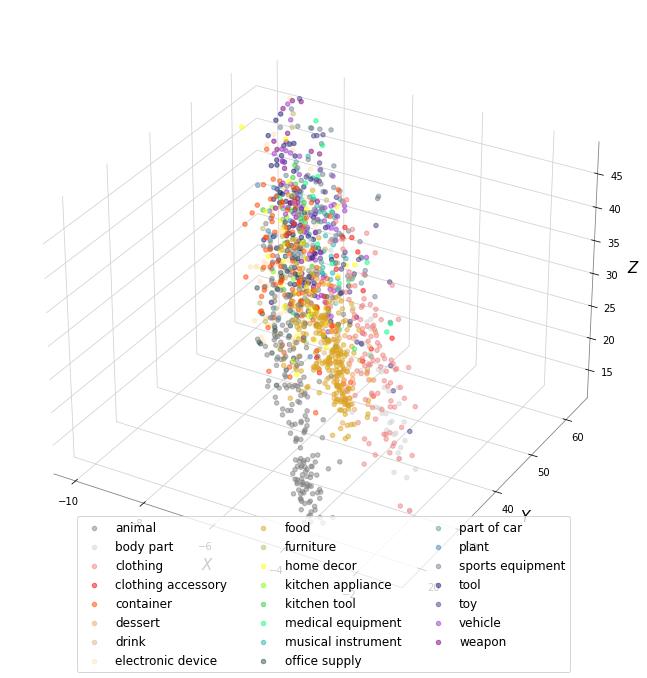

In [88]:
# 49d
### 3d hbp space
draw_umap_rdm(dim=3, metric='hyperbolic', data=embedding_49, rdm=rdm_49, pca=False, pca_dim=3, color_coded=True, filename='hbp_category_66')

/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


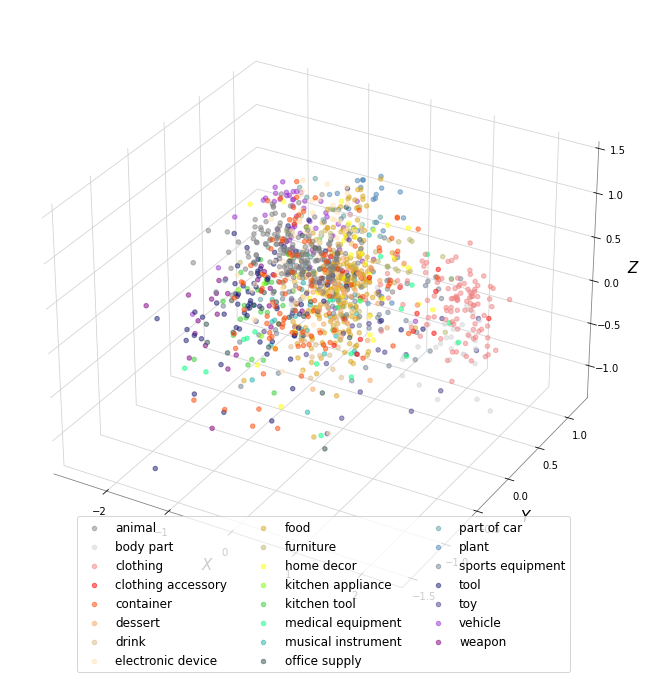

In [89]:
# 66d
### 16d eu space
draw_umap_rdm(dim=16, metric='euclidean', data=embedding_66, rdm=rdm_66, pca=True, pca_dim=3, color_coded=True)

/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


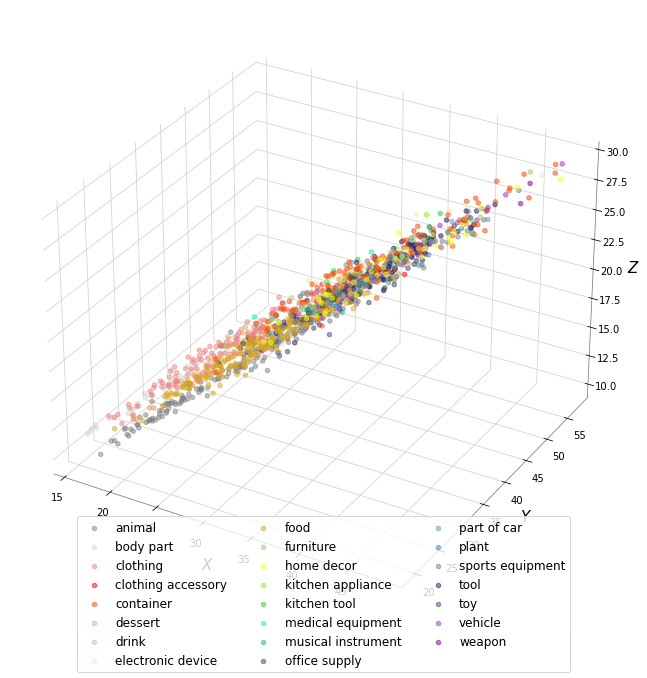

In [90]:
# 66d
### 3d hbp space
draw_umap_rdm(dim=3, metric='hyperbolic', data=embedding_66, rdm=rdm_66, pca=False, pca_dim=3, color_coded=True)

In [91]:
### UMAP coordinates --> radius & mem
def umap_analysis(dim, data, rdm, metric):
    mapper = None
    if metric == 'hyperbolic':
        mapper = umap.UMAP(n_components=dim, metric='precomputed', output_metric='hyperboloid', random_state=42).fit(rdm)
    else:
        mapper = umap.UMAP(n_components=dim, metric='precomputed', random_state=42).fit(rdm)
    
    feature = mapper.embedding_[:, :] 
    z_embedding = (data.T/np.sqrt((data**2).sum(axis=1))).T
    concept = z_embedding@feature
    radius = np.sqrt((concept**2).sum(1))
    concept = pd.DataFrame(concept)
    concept = concept.merge(cat_concept_mem[['bigcat', 'cat_name', 'cr']], how='left', left_index=True, right_index=True)
    concept['radius'] = radius
    
    zscore_mem = stats.zscore(concept['cr'])
    concept_constant = sm.add_constant(stats.zscore(concept['radius']), prepend=False)
    mod = sm.OLS(zscore_mem, concept_constant)

    res = mod.fit()
    print(res.summary())

    return concept

In [92]:
# 49d, 16d eu
umap_eu = umap_analysis(dim=16, data=embedding_49, rdm=rdm_49, metric='euclidean')
umap_eu

/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     46.55
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           1.20e-11
Time:                        15:40:16   Log-Likelihood:                -2607.7
No. Observations:                1854   AIC:                             5219.
Df Residuals:                    1852   BIC:                             5230.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius        -0.1566      0.023     -6.823      0.0

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,bigcat,cat_name,cr,radius
0,7.646443,7.509499,11.091935,7.039863,8.148240,8.490121,8.259512,9.050442,6.002996,-1.844729,7.531909,7.382513,11.510466,7.876018,12.770569,-0.373587,1,animal,0.779739,32.931398
1,19.427332,19.532738,28.384998,18.416022,21.026545,21.201770,21.545845,23.137683,15.972710,-4.968286,19.363545,20.417633,29.184801,19.555663,32.769468,-1.401002,13,home decor,0.798485,84.714986
2,18.270546,18.372284,26.518329,17.411510,20.032722,19.768148,20.043578,21.801048,14.925154,-4.646360,18.254674,19.043152,27.169648,18.484943,30.785866,-1.183739,18,musical instrument,0.752845,79.474108
3,17.762152,17.695691,25.584304,16.689299,18.981807,19.415626,19.288265,20.842381,14.627780,-4.445672,17.701981,18.536266,26.363335,18.003901,29.749504,-1.191348,99,NaN,0.761851,76.822821
4,16.901244,16.799043,24.167160,15.581801,17.460108,17.797612,18.128293,19.376760,13.760378,-4.188058,16.199621,16.705146,25.088641,16.408008,28.030913,-0.848305,9,electronic device,0.794466,71.790668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,14.921170,14.633777,21.650875,14.768088,16.499532,16.351274,16.351901,17.763639,12.814988,-3.860986,15.320797,15.602578,22.260727,15.268521,25.627510,-0.755892,99,NaN,0.722655,65.494142
1850,13.018232,12.812387,18.529266,11.963674,13.994431,14.183442,13.884427,15.205827,10.567924,-3.374188,12.852428,13.456196,19.138841,13.485203,21.670620,-1.058763,10,food,0.843158,55.940204
1851,11.925281,11.881398,17.304029,10.893389,12.537721,12.957829,12.941221,14.016018,9.547832,-2.909383,11.621120,11.852560,17.925067,11.951698,19.790348,-0.658016,1,animal,0.800163,51.204494
1852,15.527319,15.295518,22.055010,14.387151,16.563531,16.658020,16.289212,18.114059,12.915338,-3.797061,15.468719,15.699405,22.730379,15.789225,25.745595,-0.608269,99,NaN,0.797468,66.407179


In [93]:
# 49d, 3d hbp
umap_hbp = umap_analysis(dim=3, data=embedding_49, rdm=rdm_49, metric='hyperbolic')
umap_hbp

/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     188.8
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           5.55e-41
Time:                        15:40:18   Log-Likelihood:                -2540.7
No. Observations:                1854   AIC:                             5085.
Df Residuals:                    1852   BIC:                             5097.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius        -0.3042      0.022    -13.740      0.0

,0,1,2,bigcat,cat_name,cr,radius
0,-3.761487,19.305093,13.653061,1,animal,0.779739,23.942462
1,-8.105234,52.755890,39.952771,13,home decor,0.798485,66.671603
2,-7.722493,52.288465,38.624740,18,musical instrument,0.752845,65.464426
3,-7.315392,47.249420,35.072683,99,NaN,0.761851,59.296844
4,-7.045226,39.683127,30.158512,9,electronic device,0.794466,50.338073
...,...,...,...,...,...,...,...
1849,-7.370763,47.482478,35.456064,99,NaN,0.722655,59.716383
1850,-4.936713,36.615056,26.707225,10,food,0.843158,45.588478
1851,-5.101333,27.836858,20.508166,1,animal,0.800163,34.949952
1852,-5.687960,41.043263,29.830466,99,NaN,0.797468,51.056430


In [94]:
# umap_eu.to_csv('./data/umap_eu.csv')
# umap_hbp.to_csv('./data/umap_hbp.csv')
umap_eu = pd.read_csv('./figures_v2/umap/eu_data.csv', index_col=0)
umap_hbp = pd.read_csv('./figures_v2/umap/hbp_data.csv', index_col=0)
umap_hbp

,Unnamed: 0.1,0,1,2,bigcat,cat_name,cr,radius,within_cat_distance_raw,within_cat_distance,between_cat_distance,between_cat_distance_eu,between_cat_distance_resid
0,0,-3.761487,19.305093,13.653061,1,animal,0.779739,23.942462,-13.343422,-13.343422,70.849484,30.497747,0.969845
1,1,-8.105234,52.755890,39.952771,13,home decor,0.798485,66.671603,11.155166,11.155166,110.023042,14.799944,0.635879
2,2,-7.722493,52.288465,38.624740,18,musical instrument,0.752845,65.464426,4.460485,4.460485,108.515113,13.942604,0.244110
3,3,-7.315392,47.249420,35.072683,99,other,0.761851,59.296844,2.193398,2.193398,101.132101,10.999106,-1.436333
4,4,-7.045226,39.683127,30.158512,9,electronic device,0.794466,50.338073,-4.971032,-4.971032,94.308562,9.100504,0.023441
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1849,-7.370763,47.482478,35.456064,99,other,0.722655,59.716383,2.566467,2.566467,101.588886,11.220031,-1.367454
1850,1850,-4.936713,36.615056,26.707225,10,food,0.843158,45.588478,-0.608873,-0.608873,90.170846,11.440839,0.277220
1851,1851,-5.101333,27.836858,20.508166,1,animal,0.800163,34.949952,-3.366772,-3.366772,80.962507,19.588130,0.905301
1852,1852,-5.687960,41.043263,29.830466,99,other,0.797468,51.056430,-5.444335,-5.444335,93.087725,8.906304,-1.861590


In [95]:
# umap_hbp: 3 predictors
zscore_mem = stats.zscore(umap_hbp[umap_hbp['bigcat']!=99]['cr'])
concept_constant = sm.add_constant(stats.zscore(umap_hbp[umap_hbp['bigcat']!=99][['radius', 'within_cat_distance', 'between_cat_distance_resid']]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     62.77
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           6.16e-38
Time:                        15:40:18   Log-Likelihood:                -1790.4
No. Observations:                1324   AIC:                             3589.
Df Residuals:                    1320   BIC:                             3610.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
radius              

In [96]:
# umap_eu: 3 predictors
zscore_mem = stats.zscore(umap_eu[umap_eu['bigcat']!=99]['cr'])
concept_constant = sm.add_constant(stats.zscore(umap_eu[umap_eu['bigcat']!=99][['radius', 'within_cat_distance', 'between_cat_distance']]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     17.22
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           5.68e-11
Time:                        15:40:18   Log-Likelihood:                -1853.3
No. Observations:                1324   AIC:                             3715.
Df Residuals:                    1320   BIC:                             3735.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
radius                  -0.1020 

In [97]:
# 66d, 16 eu
umap_analysis(dim=16, data=embedding_66, rdm=rdm_66, metric='euclidean')

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     32.95
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           1.10e-08
Time:                        15:40:19   Log-Likelihood:                -2614.4
No. Observations:                1854   AIC:                             5233.
Df Residuals:                    1852   BIC:                             5244.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius        -0.1322      0.023     -5.740      0.0

/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,bigcat,cat_name,cr,radius
0,1.914197,11.530375,24.353052,19.200171,16.217277,19.907099,13.185617,23.680825,3.695601,5.914701,8.338369,9.802366,7.823862,21.152186,8.763561,28.015039,1,animal,0.779739,63.849762
1,3.441055,21.134678,45.084724,36.782955,30.014878,36.557289,25.089554,44.930727,7.604435,11.696407,15.609583,17.804080,15.146522,39.582267,16.260157,52.033485,13,home decor,0.798485,119.386116
2,2.454472,16.907255,35.765101,29.315053,23.808209,29.546550,19.788856,35.590018,5.548984,9.532176,12.431243,14.329254,11.725736,31.620167,12.966118,41.407217,18,musical instrument,0.752845,95.026285
3,2.856878,17.375520,36.557612,30.094839,24.729584,29.974691,20.139797,36.837352,6.161710,9.427087,13.031105,14.944992,12.324764,32.024062,13.575369,42.685992,99,NaN,0.761851,97.615005
4,2.934536,16.794431,35.314504,27.984140,23.413010,29.125665,19.097779,34.637767,5.214000,8.623292,12.043875,14.353391,11.342299,30.521880,12.741070,40.763156,9,electronic device,0.794466,92.836892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,2.626043,18.003804,37.150861,30.002114,25.206421,29.939382,20.765973,36.958861,6.331626,9.924136,13.160948,14.984632,12.140477,33.156475,13.612119,43.147705,99,NaN,0.722655,98.845053
1850,1.974521,12.695757,26.766694,21.867406,18.171142,22.309680,14.736442,27.226161,4.692184,6.736627,9.448616,10.914362,9.371495,23.396579,9.898563,31.787021,10,food,0.843158,71.871263
1851,2.171683,12.167931,26.043315,20.667651,17.127916,21.206311,14.190383,25.363510,3.967379,6.360048,8.793124,10.332453,8.417713,22.501823,9.272470,29.786803,1,animal,0.800163,68.092729
1852,2.367512,15.220608,32.273322,26.258391,21.616549,26.743496,17.840612,31.867012,5.010501,8.518906,11.252597,13.247974,10.370979,28.155008,11.803471,37.606452,99,NaN,0.797468,85.663654


In [98]:
# 66d, 3d hbp
umap_analysis(dim=3, data=embedding_66, rdm=rdm_66, metric='hyperbolic')

/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     349.4
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           1.45e-71
Time:                        15:40:21   Log-Likelihood:                -2470.5
No. Observations:                1854   AIC:                             4945.
Df Residuals:                    1852   BIC:                             4956.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius        -0.3984      0.021    -18.693      0.0

,0,1,2,bigcat,cat_name,cr,radius
0,23.972798,28.500048,14.562551,1,animal,0.779739,39.987694
1,48.084132,56.579607,28.133261,13,home decor,0.798485,79.402872
2,36.041257,42.670033,21.952849,18,musical instrument,0.752845,60.013594
3,36.107661,42.339206,21.755645,99,NaN,0.761851,59.746796
4,35.932617,43.879320,22.960692,9,electronic device,0.794466,61.186118
...,...,...,...,...,...,...,...
1849,39.755471,47.682142,25.190030,99,NaN,0.722655,66.997178
1850,24.755061,31.324167,15.233887,10,food,0.843158,42.732748
1851,26.841743,31.470313,15.929493,1,animal,0.800163,44.323905
1852,29.990215,36.986125,19.583156,99,NaN,0.797468,51.486760


In [99]:
### Dimensionality reduction (MDS) using Albatross-tested model embeddings
def draw_mds(data, embed_col, pca=False, pca_dim=3, color_coded=False, file_name=None):
    mapper = None
    if pca:
        concept = PCA(n_components=pca_dim).fit_transform(data[embed_col])
        concept = pd.DataFrame(concept).merge(data['cat_name'], how='left', left_index=True, right_index=True)
    else:
        concept = data.iloc[:, 1:]
        col_names = concept.columns
        concept.columns = [int(col_names[c]) if c < 3 else col_names[c] for c in range(len(col_names))]
        print(concept.columns)
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(projection='3d')

    # Set background color of the 3D plot area
    ax.set_facecolor('white') 

    # Set grid color to grey
    ax.xaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')
    ax.yaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')
    ax.zaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')

    ax.xaxis.line.set_color("grey")
    ax.yaxis.line.set_color("grey")
    ax.zaxis.line.set_color("grey")

    # Set background color to white
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')

    if color_coded:
        groups = concept.groupby("cat_name")
        i = 3
        for name, group in groups:
            ax.scatter(group[0], group[1], group[2], label=name, alpha=0.7, color=color_names[i])
            i = i+6
        fig.legend(loc='lower center', ncol=3, facecolor='white',fontsize=12, markerscale=1)
    else:
        ax.scatter(concept[0], concept[1], concept[2])
        
    ax.set_xlabel('$X$', fontsize=15)
    ax.set_ylabel('$Y$', fontsize=15)
    ax.set_zlabel('$Z$', fontsize=15)

    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    plt.tight_layout(pad=5)

    if file_name:
        plt.savefig(file_name)

In [100]:
eu_data = pd.read_csv('./eu_data.csv', index_col = 0)
hbp_data = pd.read_csv('./hbp_data.csv', index_col = 0)

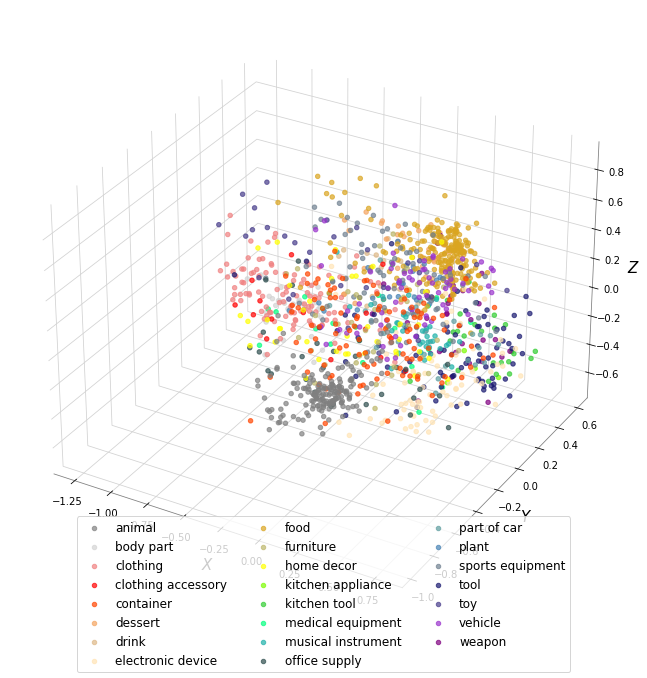

In [101]:
draw_mds(data=eu_data, embed_col=[str(i) for i in range(16)], pca=True, pca_dim=3, color_coded=True, file_name='../outputs/PCA_3d_eu_space.png')

Index([                           0,                            1,
                                  2,                         'cr',
                           'bigcat',                   'cat_name',
                        'human_typ',                     'radius',
          'within_cat_distance_raw',        'within_cat_distance',
             'between_cat_distance',    'between_cat_distance_eu',
       'between_cat_distance_resid'],
      dtype='object')


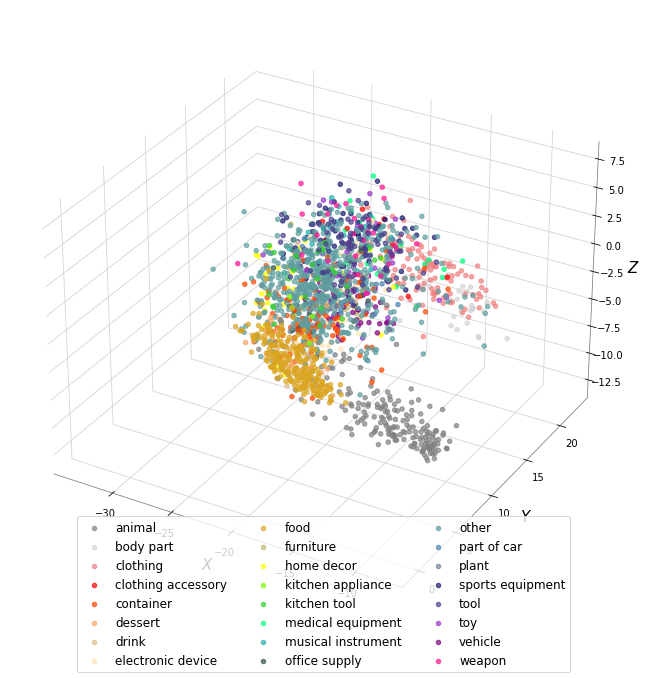

In [102]:
draw_mds(data=hbp_data, embed_col=[str(i) for i in range(3)], pca=False, pca_dim=3, color_coded=True)

# Full feature space vs. reduced feature space

### 49-feature space
* All 49 features
* Radius (in 49D space)

### Reduced MDS spaces (3D Hyperbolic & 16D Euclidean)
* Radius

In [103]:
# original 49-feature model
original_embed = pd.DataFrame(embedding_49)
original_embed['radius'] = np.sqrt((original_embed**2).sum(1))
original_embed = original_embed.merge(cat_concept_mem[['cat_name', 'cr']], how='left', left_index=True, right_index=True)
original_embed = original_embed.merge(hbp_data['bigcat'], how='left', left_index=True, right_index=True)
original_embed

,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,radius,cat_name,cr,bigcat
0,0.023445,0.224910,2.634757,0.003635,0.023814,0.056149,0.036793,0.049455,0.037291,0.121514,...,0.017426,0.005558,0.032282,0.036386,0.043167,0.008170,2.654254,animal,0.779739,1
1,1.216263,0.212026,0.030790,0.086180,0.078124,0.091531,0.033066,0.012192,0.948988,0.033112,...,0.011658,0.053764,0.019490,0.433739,0.007475,0.078402,2.631684,home decor,0.798485,13
2,0.941345,0.043994,0.022709,0.075293,0.294857,0.002652,0.005566,0.171899,0.032501,0.304940,...,0.022446,0.026673,0.015072,0.021458,0.005046,0.058082,2.547773,musical instrument,0.752845,18
3,0.245730,1.090243,0.790466,0.037349,0.018132,0.889879,0.214732,0.026396,1.140915,0.056548,...,0.011881,0.013770,0.014994,0.050214,0.050764,0.002238,2.502564,NaN,0.761851,99
4,0.816049,0.045588,0.010806,0.213462,1.407203,0.004317,0.419202,0.097060,0.024306,0.068508,...,0.014482,0.082867,0.079964,0.871001,0.000197,0.078672,2.603126,electronic device,0.794466,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1.667489,0.192158,0.638314,0.321197,0.016769,0.068840,0.702188,0.070288,1.296791,0.052246,...,0.015621,0.021683,0.039394,0.034754,0.009601,0.002418,2.514584,NaN,0.722655,99
1850,0.058609,2.311476,0.587398,0.016274,0.082293,0.226948,0.019507,0.006364,0.102872,0.029175,...,0.054714,0.025591,0.007402,0.006500,0.032593,0.038133,2.662016,food,0.843158,10
1851,0.059386,0.101553,2.455842,0.167662,0.047168,0.014876,0.008409,0.121855,0.042200,0.103440,...,0.026153,0.008130,0.025275,0.229396,0.042420,0.022109,2.629053,animal,0.800163,1
1852,1.893253,0.005506,0.030761,1.093658,0.218929,0.110647,0.212005,0.057070,0.018604,0.364859,...,0.037380,0.012700,0.069102,0.081612,0.043618,0.071729,2.449999,NaN,0.797468,99


In [104]:
zscore_mem = stats.zscore(original_embed['cr'])
concept_constant = sm.add_constant(stats.zscore(original_embed['radius']), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)

res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.989
Date:                Tue, 29 Sep 2026   Prob (F-statistic):              0.159
Time:                        15:40:23   Log-Likelihood:                -2629.7
No. Observations:                1854   AIC:                             5263.
Df Residuals:                    1852   BIC:                             5274.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius        -0.0328      0.023     -1.410      0.1

In [105]:
zscore_mem = stats.zscore(original_embed['cr'])
concept_constant = sm.add_constant(stats.zscore(original_embed.iloc[:,:49]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)

res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.385
Model:                            OLS   Adj. R-squared:                  0.368
Method:                 Least Squares   F-statistic:                     23.04
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          2.28e-154
Time:                        15:40:23   Log-Likelihood:                -2180.1
No. Observations:                1854   AIC:                             4460.
Df Residuals:                    1804   BIC:                             4737.
Df Model:                          49                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
0             -0.2546      0.039     -6.495      0.0

In [106]:
coef = res.params[0:49]
pos_feat = coef[coef > 0] # 20 coef > 0
pos_feat.index.to_list()

[1, 3, 9, 10, 13, 15, 16, 22, 24, 25, 26, 29, 34, 36, 40, 42, 44, 45, 46, 48]

In [107]:
# Hbp radius
zscore_mem = stats.zscore(hbp_data['cr'])
concept_constant = sm.add_constant(stats.zscore(hbp_data['radius']), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)

res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     71.58
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           5.33e-17
Time:                        15:40:23   Log-Likelihood:                -2595.6
No. Observations:                1854   AIC:                             5195.
Df Residuals:                    1852   BIC:                             5206.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius        -0.1929      0.023     -8.460      0.0

In [108]:
# Eu radius
zscore_mem = stats.zscore(eu_data['cr'])
concept_constant = sm.add_constant(stats.zscore(eu_data['radius']), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)

res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     16.09
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           6.29e-05
Time:                        15:40:23   Log-Likelihood:                -2622.7
No. Observations:                1854   AIC:                             5249.
Df Residuals:                    1852   BIC:                             5260.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius        -0.0928      0.023     -4.011      0.0

In [109]:
# Are all concepts positive? 
original_embed


,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,radius,cat_name,cr,bigcat
0,0.023445,0.224910,2.634757,0.003635,0.023814,0.056149,0.036793,0.049455,0.037291,0.121514,...,0.017426,0.005558,0.032282,0.036386,0.043167,0.008170,2.654254,animal,0.779739,1
1,1.216263,0.212026,0.030790,0.086180,0.078124,0.091531,0.033066,0.012192,0.948988,0.033112,...,0.011658,0.053764,0.019490,0.433739,0.007475,0.078402,2.631684,home decor,0.798485,13
2,0.941345,0.043994,0.022709,0.075293,0.294857,0.002652,0.005566,0.171899,0.032501,0.304940,...,0.022446,0.026673,0.015072,0.021458,0.005046,0.058082,2.547773,musical instrument,0.752845,18
3,0.245730,1.090243,0.790466,0.037349,0.018132,0.889879,0.214732,0.026396,1.140915,0.056548,...,0.011881,0.013770,0.014994,0.050214,0.050764,0.002238,2.502564,NaN,0.761851,99
4,0.816049,0.045588,0.010806,0.213462,1.407203,0.004317,0.419202,0.097060,0.024306,0.068508,...,0.014482,0.082867,0.079964,0.871001,0.000197,0.078672,2.603126,electronic device,0.794466,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1.667489,0.192158,0.638314,0.321197,0.016769,0.068840,0.702188,0.070288,1.296791,0.052246,...,0.015621,0.021683,0.039394,0.034754,0.009601,0.002418,2.514584,NaN,0.722655,99
1850,0.058609,2.311476,0.587398,0.016274,0.082293,0.226948,0.019507,0.006364,0.102872,0.029175,...,0.054714,0.025591,0.007402,0.006500,0.032593,0.038133,2.662016,food,0.843158,10
1851,0.059386,0.101553,2.455842,0.167662,0.047168,0.014876,0.008409,0.121855,0.042200,0.103440,...,0.026153,0.008130,0.025275,0.229396,0.042420,0.022109,2.629053,animal,0.800163,1
1852,1.893253,0.005506,0.030761,1.093658,0.218929,0.110647,0.212005,0.057070,0.018604,0.364859,...,0.037380,0.012700,0.069102,0.081612,0.043618,0.071729,2.449999,NaN,0.797468,99


<AxesSubplot:>

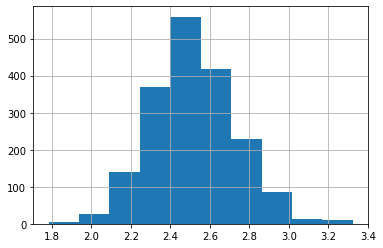

In [110]:
original_embed['radius'].hist()

In [111]:
hbp_data

,Unnamed: 0.1,0,1,2,cr,bigcat,cat_name,human_typ,radius,within_cat_distance_raw,within_cat_distance,between_cat_distance,between_cat_distance_eu,between_cat_distance_resid
0,0,-8.362256,5.447828,-8.557188,0.779739,1,animal,4.874352,13.146544,-5.591425,-5.591425,34.789327,16.110352,0.756365
1,1,-26.123590,12.240625,0.518939,0.798485,13,home decor,6.374555,28.853841,2.428793,2.428793,47.796615,9.237683,0.316532
2,2,-24.385152,14.180849,0.693800,0.752845,18,musical instrument,5.342846,28.217255,4.481303,4.481303,47.097163,8.593136,0.162066
3,3,-25.107906,9.416656,-2.846510,0.761851,99,other,4.655669,26.966330,1.574353,1.574353,45.296440,9.014194,-0.567732
4,4,-20.330699,11.947785,-4.992442,0.794466,9,electronic device,5.288886,24.104177,0.600360,0.600360,43.066686,7.206293,-0.347178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1849,-17.319193,11.068469,0.200732,0.722655,99,other,NaN,20.554945,-5.428363,-5.428363,38.835674,7.505903,-1.539669
1850,1850,-19.551059,2.813812,-2.150868,0.843158,10,food,NaN,19.869265,-0.333862,-0.333862,40.724176,11.145902,0.935849
1851,1851,-14.748351,9.486465,-8.609210,0.800163,1,animal,NaN,19.535234,-0.312382,-0.312382,40.299060,11.001376,0.796699
1852,1852,-15.327696,12.965252,0.600495,0.797468,99,other,NaN,20.084736,-5.026055,-5.026055,38.798662,8.592519,-1.174132


<AxesSubplot:>

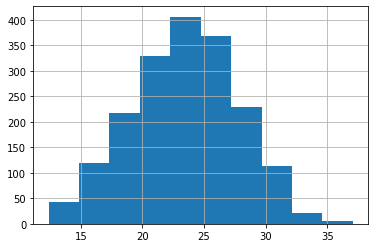

In [112]:
hbp_data['radius'].hist()

In [113]:
eu_data

,Unnamed: 0.1,0,1,2,3,4,5,6,7,8,...,14,15,cr,bigcat,cat_name,human_typ,radius,within_cat_distance,between_cat_distance,between_cat_distance_resid
0,0,-0.684000,-0.102510,-0.001977,-0.161126,-0.083603,-0.545069,-0.156659,-0.315357,-0.040165,...,0.004923,-0.195545,0.779739,1,animal,4.874352,1.039172,-0.138350,1.181085,-0.056070
1,1,-0.480093,-0.347490,-0.039716,-0.060931,-0.204651,-0.033460,-0.016872,-0.271556,0.130586,...,0.023103,-0.337668,0.798485,13,home decor,6.374555,0.984779,-0.093797,1.120043,-0.101247
2,2,-0.455151,-0.138925,0.128791,-0.228593,0.235532,0.292837,0.052048,-0.359713,0.325356,...,-0.195335,-0.489841,0.752845,18,musical instrument,5.342846,1.126360,0.013479,1.262936,0.000351
3,3,-0.253700,-0.144712,0.092875,-0.197541,-0.147820,-0.085465,0.493489,-0.394751,-0.097714,...,0.203924,-0.387516,0.761851,99,NaN,4.655669,1.139281,-0.079634,1.135663,-0.130691
4,4,-0.167391,0.140108,-0.122743,0.134071,0.131831,-0.141127,0.153950,-0.148427,0.359455,...,-0.346259,-0.305948,0.794466,9,electronic device,5.288886,0.940568,0.013629,1.202027,-0.006368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1849,-0.254174,-0.147885,-0.049687,-0.214618,0.145857,-0.548353,0.281969,-0.353209,0.008595,...,0.248313,-0.587194,0.722655,99,NaN,NaN,1.233516,-0.081852,1.132672,-0.161168
1850,1850,-0.414438,-0.129664,-0.005765,-0.085451,-0.057259,-0.095028,0.366166,-0.171491,0.163650,...,-0.075001,-0.298887,0.843158,10,food,NaN,0.993075,-0.091733,1.127115,-0.096594
1851,1851,-0.617261,-0.077546,0.023510,-0.189678,-0.028388,-0.321632,-0.269389,-0.241300,-0.047352,...,0.001311,-0.159804,0.800163,1,animal,NaN,0.936892,-0.025490,1.195054,-0.012269
1852,1852,-0.288522,0.036183,0.137136,-0.215078,0.242237,-0.553400,0.316395,-0.195523,0.222589,...,0.030411,-0.131616,0.797468,99,NaN,NaN,0.982379,-0.173561,0.984983,-0.235607


<AxesSubplot:>

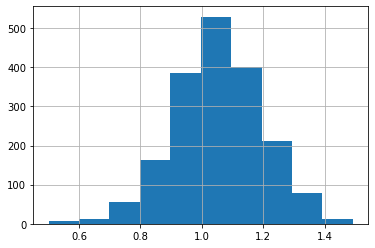

In [114]:
eu_data['radius'].hist()

In [115]:
# Features distribute around origin in scaled spaces
hbp_feature_embed = np.load(os.path.join(data_dir, 'feature_embeddings_3dhbp.npy'))
hbp_feature_embed = pd.DataFrame(hbp_feature_embed)

In [116]:
hbp_feature_embed.describe()

,0,1,2
count,49.000000,49.000000,49.000000
mean,-4.459690,3.894473,-2.442746
std,3.959107,3.124905,4.086861
min,-11.020587,-3.845814,-9.673095
25%,-6.986953,1.788412,-5.529430
50%,-5.691076,4.180354,-2.692727
75%,-2.410071,6.006424,0.604869
max,5.187516,9.722081,6.455065


In [117]:
eu_feature_embed = np.load(os.path.join(data_dir, 'feature_embeddings_16deu.npy'))
eu_feature_embed = pd.DataFrame(eu_feature_embed)
eu_feature_embed

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-0.002167,0.396248,-0.003119,-0.072051,0.520030,-0.345921,0.022020,-0.349226,-0.518061,-0.162838,-0.000548,0.094902,-0.398205,-0.243180,-0.271310,-0.165134
1,-0.009002,0.351915,0.231969,0.064496,0.498161,-0.242326,0.007349,-0.320900,-0.426479,0.383403,-0.071828,0.286294,0.003213,0.241403,0.049878,0.130863
2,-0.150438,0.288637,-0.058415,-0.210860,0.011737,0.083883,-0.162541,-0.341022,-0.372032,-0.312541,0.173726,-0.004298,-0.315850,-0.652063,-0.061664,0.092807
3,-0.119199,-0.182661,0.214283,0.031508,0.220870,-0.281601,-0.170945,-0.109908,0.158271,0.105216,0.630831,-0.273215,0.075351,-0.104882,0.048072,0.459683
4,-0.522482,-0.065728,-0.276612,-0.420141,-0.180550,-0.245932,0.079978,-0.066586,-0.457108,0.210894,-0.136346,-0.026117,-0.187646,-0.030659,0.175225,0.111854
5,0.161205,-0.097215,0.117481,-0.058478,0.071919,-0.479446,0.101368,-0.317595,-0.376371,0.128963,0.428625,0.238521,0.040820,-0.193686,0.018629,-0.295611
6,-0.163285,-0.057804,0.222757,0.344732,0.047077,-0.111494,-0.131396,-0.533935,-0.201380,0.067331,-0.218020,-0.035729,0.409653,0.368424,0.019912,-0.144546
7,-0.119505,-0.085055,0.202387,-0.350006,0.317020,-0.022777,-0.276912,0.018732,-0.042425,0.284785,-0.089698,0.381053,-0.290045,0.200746,-0.431854,0.208879
8,-0.274671,0.401402,0.308338,-0.208084,0.089895,0.340285,0.070608,0.265431,-0.205275,-0.031039,-0.314793,-0.153821,0.314119,0.091778,0.030229,-0.243557
9,0.013763,-0.032959,0.344867,0.140132,0.189337,-0.136529,-0.031641,0.203035,-0.170612,0.130973,0.643112,-0.353453,0.290273,0.263271,-0.214018,0.270882


In [118]:
eu_feature_embed.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
count,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01
mean,-1.203686e-18,-2.095829e-17,1.132881e-17,-2.832202e-18,-5.097963e-18,1.359457e-17,-4.531523e-18,2.265761e-18,-2.265761e-17,7.646944e-18,1.699321e-18,6.230844e-18,-1.472745e-17,-1.288652e-17,-1.699321e-18,-5.239573e-18
std,2.611958e-01,2.540314e-01,2.516465e-01,2.335368e-01,2.561494e-01,2.484494e-01,2.353941e-01,2.505884e-01,2.814282e-01,2.533786e-01,2.686820e-01,2.514383e-01,2.532984e-01,2.498536e-01,2.490624e-01,2.489525e-01
min,-5.308753e-01,-5.211226e-01,-5.316778e-01,-4.201412e-01,-5.488026e-01,-5.075802e-01,-4.138130e-01,-5.339346e-01,-6.324466e-01,-6.487576e-01,-5.421677e-01,-5.117444e-01,-3.982053e-01,-6.520626e-01,-4.318542e-01,-4.808536e-01
25%,-1.632851e-01,-1.826607e-01,-2.299800e-01,-2.053382e-01,-2.196624e-01,-1.856648e-01,-1.994165e-01,-1.461993e-01,-1.706121e-01,-1.887379e-01,-2.103235e-01,-1.659295e-01,-1.923947e-01,-1.783239e-01,-2.075885e-01,-2.197664e-01
50%,-2.166528e-03,-1.046655e-02,-3.119102e-03,1.397915e-02,1.173676e-02,-3.877251e-02,7.348917e-03,1.601031e-02,-4.242498e-02,5.546586e-04,-9.550453e-03,-2.611715e-02,-5.512124e-02,-3.065937e-02,-3.606385e-03,6.830979e-02
75%,1.949517e-01,1.758855e-01,2.210936e-01,1.418276e-01,1.893371e-01,2.184138e-01,1.411533e-01,1.433007e-01,2.142816e-01,1.937473e-01,1.670205e-01,1.766291e-01,2.161271e-01,2.007463e-01,1.752247e-01,1.829116e-01
max,5.502223e-01,5.650265e-01,5.263910e-01,5.057710e-01,5.200301e-01,4.721959e-01,4.969042e-01,5.824811e-01,6.425304e-01,3.834030e-01,6.431120e-01,5.160900e-01,4.436951e-01,5.022923e-01,4.963359e-01,5.059488e-01


In [119]:
# possible explanation: more balanced loadings on each feature --> smaller radius
# std & max diff of feature loadings of each concept --> related to radius? 

original_embed['std'] = original_embed.iloc[:, :49].std(axis=1)
original_embed['max_diff'] = original_embed.iloc[:, :49].max(axis=1) - original_embed.iloc[:, :49].min(axis=1)
original_embed['mean'] = original_embed.iloc[:, :49].mean(axis=1) # heavy loading?
original_embed

,0,1,2,3,4,5,6,7,8,9,...,46,47,48,radius,cat_name,cr,bigcat,std,max_diff,mean
0,0.023445,0.224910,2.634757,0.003635,0.023814,0.056149,0.036793,0.049455,0.037291,0.121514,...,0.036386,0.043167,0.008170,2.654254,animal,0.779739,1,0.373943,2.633565,0.082447
1,1.216263,0.212026,0.030790,0.086180,0.078124,0.091531,0.033066,0.012192,0.948988,0.033112,...,0.433739,0.007475,0.078402,2.631684,home decor,0.798485,13,0.313795,1.213264,0.211860
2,0.941345,0.043994,0.022709,0.075293,0.294857,0.002652,0.005566,0.171899,0.032501,0.304940,...,0.021458,0.005046,0.058082,2.547773,musical instrument,0.752845,18,0.312023,1.605982,0.192616
3,0.245730,1.090243,0.790466,0.037349,0.018132,0.889879,0.214732,0.026396,1.140915,0.056548,...,0.050214,0.050764,0.002238,2.502564,NaN,0.761851,99,0.310667,1.138677,0.182397
4,0.816049,0.045588,0.010806,0.213462,1.407203,0.004317,0.419202,0.097060,0.024306,0.068508,...,0.871001,0.000197,0.078672,2.603126,electronic device,0.794466,9,0.330101,1.521816,0.177618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1.667489,0.192158,0.638314,0.321197,0.016769,0.068840,0.702188,0.070288,1.296791,0.052246,...,0.034754,0.009601,0.002418,2.514584,NaN,0.722655,99,0.326711,1.667382,0.156467
1850,0.058609,2.311476,0.587398,0.016274,0.082293,0.226948,0.019507,0.006364,0.102872,0.029175,...,0.006500,0.032593,0.038133,2.662016,food,0.843158,10,0.356952,2.307301,0.140730
1851,0.059386,0.101553,2.455842,0.167662,0.047168,0.014876,0.008409,0.121855,0.042200,0.103440,...,0.229396,0.042420,0.022109,2.629053,animal,0.800163,1,0.356948,2.454553,0.127468
1852,1.893253,0.005506,0.030761,1.093658,0.218929,0.110647,0.212005,0.057070,0.018604,0.364859,...,0.081612,0.043618,0.071729,2.449999,NaN,0.797468,99,0.317433,1.887747,0.154249


In [120]:
import scipy.stats as stats
# more spread out loadings, lighter mean loadings --> smaller radius
# closer to root may mean: loadings on features cancel each other out, or generally smaller loadings

print(stats.spearmanr(original_embed['std'], hbp_data['radius'])) # greater std --> smaller radius
print(stats.spearmanr(original_embed['max_diff'], hbp_data['radius'])) # greater max-min --> smaller radius
print(stats.spearmanr(original_embed['mean'], hbp_data['radius'])) # heavy loading on features --> longer radius
print(stats.spearmanr(original_embed['radius'], hbp_data['radius']))
print(stats.spearmanr(original_embed['max_diff'], original_embed['mean']))

SignificanceResult(statistic=-0.5024097226259903, pvalue=3.7646370425499797e-119)
SignificanceResult(statistic=-0.7076580361486428, pvalue=1.0875712036109552e-281)
SignificanceResult(statistic=0.7418312376889228, pvalue=0.0)
SignificanceResult(statistic=-0.09091839279781046, pvalue=8.845554722897054e-05)
SignificanceResult(statistic=-0.5531282759191697, pvalue=4.487787181764533e-149)


In [121]:
# what are the positive vs. negative features?
# hbp concepts: x < 0, y > 0, z around 0
# hbp features: (positive -- 36/49) x < 0, y > 0; (negative -- 13/49) x > 0 or y < 0

# but heavy loadings on negative features correlate positively with radius
#  --> they don't bring concepts closer to root
hbp_neg_feat = hbp_feature_embed[(hbp_feature_embed[0] > 0) | (hbp_feature_embed[1]<0)]
print(stats.spearmanr(original_embed.iloc[:, hbp_neg_feat.index].mean(axis=1), hbp_data['radius']))

SignificanceResult(statistic=0.2619993251581503, pvalue=1.7698846992110136e-30)


In [122]:
print(stats.spearmanr(original_embed.iloc[:, pos_feat.index.to_list()].mean(axis=1), hbp_data['radius']))
neg_feat = [i for i in range(0, 49) if i not in pos_feat.index.to_list()]
print(stats.spearmanr(original_embed.iloc[:, neg_feat].mean(axis=1), hbp_data['radius']))


SignificanceResult(statistic=0.12409907207856935, pvalue=8.294599190726042e-08)
SignificanceResult(statistic=0.6388049852657678, pvalue=3.83238960995546e-213)


In [123]:
# in eu space? no effect
print(stats.spearmanr(original_embed['std'], eu_data['radius'])) 
print(stats.spearmanr(original_embed['max_diff'], eu_data['radius'])) 
print(stats.spearmanr(original_embed['mean'], eu_data['radius'])) # heavy loading on features --> smaller radius
print(stats.spearmanr(original_embed['radius'], eu_data['radius']))


SignificanceResult(statistic=0.07871819892988934, pvalue=0.0006927429463212189)
SignificanceResult(statistic=0.044903358305833536, pvalue=0.05322087561796671)
SignificanceResult(statistic=-0.24105540399615835, pvalue=6.417672534320049e-26)
SignificanceResult(statistic=-0.04214698095408414, pvalue=0.06962367428060731)


In [124]:
zscore_mem = stats.zscore(original_embed['cr'])
concept_constant = sm.add_constant(stats.zscore(original_embed.iloc[:,:49]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)

res = mod.fit()
coef_49 = res.params[:-1]
coef_49

0    -0.254649
1     0.038404
2    -0.038768
3     0.037335
4    -0.121457
5    -0.196873
6    -0.089102
7    -0.154644
8    -0.033181
9     0.180345
10    0.006305
11   -0.087029
12   -0.059684
13    0.000661
14   -0.047120
15    0.071825
16    0.099628
17   -0.032649
18   -0.092329
19   -0.019005
20   -0.066425
21   -0.047566
22    0.026043
23   -0.105796
24    0.087449
25    0.003171
26    0.069322
27   -0.031138
28   -0.082663
29    0.002222
30   -0.007130
31   -0.002065
32   -0.004440
33   -0.019043
34    0.021088
35   -0.010422
36    0.067944
37   -0.032236
38   -0.023785
39   -0.008334
40    0.047976
41   -0.014682
42    0.023027
43   -0.011398
44    0.021815
45    0.000259
46    0.025092
47   -0.025601
48    0.007979
dtype: float64

In [125]:
# "highly-occurring" features are centered and predict concept memorability? No
# features closer to the root in hbp space are not more or less predictive of concept memorability
hbp_feature_embed['r'] = np.sqrt((hbp_feature_embed[[0,1,2]]**2).sum(axis=1))
print(stats.spearmanr(hbp_feature_embed['r'], coef_49))
print(stats.spearmanr(hbp_feature_embed[0], coef_49))
print(stats.spearmanr(hbp_feature_embed[1], coef_49))
print(stats.spearmanr(hbp_feature_embed[2], coef_49))

SignificanceResult(statistic=0.009285714285714284, pvalue=0.9495090411242234)
SignificanceResult(statistic=0.3181632653061224, pvalue=0.02588763762888293)
SignificanceResult(statistic=0.24551020408163265, pvalue=0.0890671667298852)
SignificanceResult(statistic=0.151734693877551, pvalue=0.2979848239192306)


In [126]:
# features with higher correlation with all other features are not more centered in hbp space
# but may be somewhat more predictive of concept memorability
coef_embed = pd.read_csv('./data/coef_embed.csv', header=None)
coef_embed['avg_coef'] = abs(coef_embed).mean(axis=1)
print(stats.spearmanr(hbp_feature_embed['r'], coef_embed['avg_coef']))
print(stats.spearmanr(coef_49, coef_embed['avg_coef']))

SignificanceResult(statistic=0.10622448979591836, pvalue=0.46757210874806054)
SignificanceResult(statistic=0.3092857142857142, pvalue=0.0305843943664083)


# Sparsity
* sparisty of features exists in both spaces?

In [127]:
# sparsity = distance to the 5-th proximal neighbor
from hyperbolicMDS.mds import cart_to_polar, poincare_dist_vec

hbp_feature_distance = pd.DataFrame(poincare_dist_vec(hbp_feature_embed[[0,1,2]].values))
hbp_feature_distance

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,4.214685e-08,3.606085,7.062219,7.746601,10.532487,9.056012,8.651650,8.142053,5.003073,9.243557,...,4.928246,11.029518,10.133178,7.951019,7.297887,5.909401,10.459047,7.959004,10.529521,8.288206
1,3.606085e+00,0.000000,9.380953,10.260236,12.788388,10.363153,7.613242,9.124045,7.222653,11.844041,...,8.502714,13.440394,12.486656,9.361378,10.037493,8.781640,13.187257,10.992757,13.185610,11.495373
2,7.062219e+00,9.380953,0.000000,12.903582,9.905304,13.322041,14.668481,13.252665,6.241076,14.520153,...,11.704548,16.351027,16.951216,14.485669,11.059670,11.994989,15.311372,14.986456,13.748414,13.837447
3,7.746601e+00,10.260236,12.903582,0.000011,16.326510,14.797364,15.359255,14.898359,11.045157,10.318638,...,12.101897,13.153450,17.657989,15.232692,12.635731,11.001310,14.139401,15.580202,16.805905,14.011848
4,1.053249e+01,12.788388,9.905304,16.326510,0.000000,16.618974,18.083503,16.667923,9.757961,17.952142,...,15.190281,19.767422,20.406178,17.927692,14.620924,15.444500,18.767821,18.451475,17.483620,17.343798
5,9.056012e+00,10.363153,13.322041,14.797364,16.618974,0.000122,15.786652,14.627983,11.182288,16.465672,...,13.852709,18.062259,18.674156,16.027827,14.389306,13.878298,17.677124,16.849111,17.653591,16.344804
6,8.651650e+00,7.613242,14.668481,15.359255,18.083503,15.786652,0.000000,14.726664,12.538577,16.930529,...,13.514942,18.517160,17.336804,14.070699,15.229762,13.772343,18.316723,15.900457,18.434975,16.595065
7,8.142053e+00,9.124045,13.252665,14.898359,16.667923,14.627983,14.726664,0.000061,10.936896,16.484179,...,13.048726,18.171210,17.405303,14.664669,14.229874,13.555012,17.652970,15.754399,17.025361,15.898493
8,5.003073e+00,7.222653,6.241076,11.045157,9.757961,11.182288,12.538577,10.936896,0.000002,12.655563,...,9.694530,14.457623,14.841527,12.357978,9.474679,10.050882,13.527043,12.906538,11.769679,11.960451
9,9.243557e+00,11.844041,14.520153,10.318638,17.952142,16.465672,16.930529,16.484179,12.655563,0.000000,...,13.534887,15.094661,19.171561,16.766867,14.199314,12.274092,15.604147,17.069429,18.368826,15.393519


In [128]:
hbp_sparseness = []
for i, rows in hbp_feature_distance.iterrows():
    distance = rows.values
    distance = np.delete(distance, i)
    distance = sorted(distance)
    hbp_sparseness.append(np.mean(distance))

norm = np.linalg.norm(hbp_sparseness)     # To find the norm of the array
z_hbp_sparseness = hbp_sparseness/norm  # Formula used to perform array normalization
z_hbp_sparseness

array([0.07903359, 0.09919048, 0.120211  , 0.13278821, 0.15149915,
       0.14193565, 0.14564429, 0.13666095, 0.10247832, 0.14691472,
       0.09248038, 0.11355284, 0.13698716, 0.13290555, 0.13568708,
       0.1296734 , 0.1474233 , 0.16754648, 0.14248298, 0.15133234,
       0.15064926, 0.15838448, 0.12161962, 0.13497082, 0.15418516,
       0.1656486 , 0.12880357, 0.12214001, 0.13827132, 0.15397597,
       0.16384902, 0.17526086, 0.17562228, 0.17689767, 0.1625423 ,
       0.12964344, 0.17336517, 0.12521786, 0.16034834, 0.11788332,
       0.16330504, 0.16401179, 0.14242806, 0.12748321, 0.12276386,
       0.15709382, 0.1464671 , 0.15620624, 0.14259402])

In [129]:
# sparseness in eu space

from scipy.spatial import distance

eu_feature_distance = pd.DataFrame(distance.cdist(eu_feature_embed, eu_feature_embed, 'euclidean'))
eu_feature_distance

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,0.000000,1.011613,0.949480,1.547311,1.343973,1.056965,1.456948,1.275208,1.489413,1.599348,...,1.581173,1.818447,1.493550,1.586122,1.521967,1.647895,1.703782,1.796496,1.749254,1.804657
1,1.011613,0.000000,1.449985,1.383256,1.311948,1.095096,1.043665,1.070204,1.319136,1.330954,...,1.425590,1.454443,1.306678,1.492256,1.511762,1.599983,1.543279,1.759097,1.718151,1.647504
2,0.949480,1.449985,0.000000,1.386756,1.213335,1.226719,1.595039,1.427182,1.447917,1.627613,...,1.780545,1.800908,1.587152,1.640539,1.269493,1.658334,1.733537,1.551376,1.465089,1.630857
3,1.547311,1.383256,1.386756,0.000000,1.449080,1.204821,1.402002,1.341321,1.638419,0.780897,...,1.619580,1.233823,1.597381,1.528496,1.429043,1.347296,1.306939,1.566516,1.329488,1.467143
4,1.343973,1.311948,1.213335,1.449080,0.000000,1.268086,1.412492,1.271426,1.333444,1.586659,...,1.538477,1.474220,1.366249,1.369147,1.142188,1.506928,1.616936,1.495328,1.571429,1.623268
5,1.056965,1.095096,1.226719,1.204821,1.268086,0.000000,1.232927,1.357661,1.559188,1.273577,...,1.509122,1.313722,1.314267,1.703940,1.771181,1.425991,1.534740,1.717964,1.513129,1.597000
6,1.456948,1.043665,1.595039,1.402002,1.412492,1.232927,0.000000,1.415102,1.245194,1.327698,...,1.366664,1.240866,1.088241,1.317311,1.573867,1.426048,1.445306,1.352491,1.571722,1.460146
7,1.275208,1.070204,1.427182,1.341321,1.271426,1.357661,1.415102,0.000000,1.383924,1.383095,...,1.446218,1.518641,1.315883,0.880861,1.319277,1.468403,1.399001,1.580622,1.487224,1.521884
8,1.489413,1.319136,1.447917,1.638419,1.333444,1.559188,1.245194,1.383924,0.000000,1.408974,...,1.348600,1.494865,1.431616,1.322893,1.269522,1.751603,1.272294,1.486966,1.319037,1.465784
9,1.599348,1.330954,1.627613,0.780897,1.586659,1.273577,1.327698,1.383095,1.408974,0.000000,...,1.393888,1.057098,1.795232,1.554451,1.615378,1.469783,1.312996,1.777149,1.554215,1.611602


In [130]:
eu_sparseness = []
for i, rows in eu_feature_distance.iterrows():
    distance = rows.values
    distance = np.delete(distance, i)
    distance = sorted(distance)
    eu_sparseness.append(np.mean(distance))

norm = np.linalg.norm(eu_sparseness)     # To find the norm of the array
z_eu_sparseness = eu_sparseness/norm  # Formula used to perform array normalization
z_eu_sparseness

array([0.15211709, 0.14534963, 0.14616599, 0.14262179, 0.14214624,
       0.13981496, 0.14030592, 0.14096079, 0.13952405, 0.14572686,
       0.14432896, 0.14173408, 0.14240023, 0.13979073, 0.14262198,
       0.14388265, 0.14219631, 0.14245536, 0.14028106, 0.1436725 ,
       0.1426547 , 0.14014142, 0.14601909, 0.1420565 , 0.14185233,
       0.13962295, 0.14068996, 0.14221983, 0.14297231, 0.14280052,
       0.1434792 , 0.14308769, 0.14458396, 0.14315659, 0.14167737,
       0.14219395, 0.14456411, 0.14267738, 0.13955926, 0.14356818,
       0.1434912 , 0.14183868, 0.14232429, 0.14229983, 0.14301585,
       0.14343621, 0.14561069, 0.14437545, 0.14510773])

In [131]:
stats.spearmanr(z_hbp_sparseness, z_eu_sparseness)

SignificanceResult(statistic=-0.08153061224489795, pvalue=0.5775891560361128)

In [132]:
# % of space taken up by features

### Get the range of features in hyperbolic space
r_feat, r_phi, r_theta = cart_to_polar(hbp_feature_embed[[0,1,2]].values).T
maxtheta = max(r_theta)
mintheta = min(r_theta)
maxphi = max(r_phi)
minphi = min(r_phi)
pi = np.pi
print(maxtheta, mintheta, maxphi, minphi)
print(maxtheta/pi, mintheta/pi, maxphi/pi, minphi/pi)

### Get the proportion of space that features take up
(2/3*(maxtheta-mintheta)*(maxphi-minphi)/pi*(21**3-8.4**3))/(4*pi/3*(21**3-8.4**3))

5.645237198121296 0.7622011344479969 2.9987550438261645 0.6463232518941587
1.7969348100144913 0.242616156355298 0.9545333766933747 0.20573108074836716


0.5819386882450786

In [133]:
from scipy.special import gamma

# Assuming df_16d is your pandas DataFrame with 16 columns
# --- METHOD A: BOUNDING HYPERBALL (SPHERE) ---
# Calculate radial distance (l2 norm) from origin for each data point
radii = np.linalg.norm(eu_feature_embed.values, axis=1)

r_data_max = np.max(radii)
r_data_min = np.min(radii)  # If using a spherical shell [r_min, r_max]

# Define reference outer radius (e.g., maximum possible embedding radius or 1.0)
r_ref = np.sqrt(16 * (1.0 ** 2))

# Volume of a 16D ball formula
def volume_16d_ball(r):
    return (np.pi**8 / gamma(9)) * (r**16)

# Volume occupied by data (solid hyperball vs shell)
vol_data_ball = volume_16d_ball(r_data_max)
vol_data_shell = volume_16d_ball(r_data_max) - volume_16d_ball(r_data_min)
vol_ref_ball = volume_16d_ball(r_ref)

prop_hyperball = vol_data_ball / vol_ref_ball
prop_hypershell = vol_data_shell / vol_ref_ball

print(f"Max Data Radius: {r_data_max:.4f}")
print(f"Hyperball Volume Proportion: {prop_hyperball:.6e}")
print(f"Hypershell Volume Proportion: {prop_hypershell:.6e}")

Max Data Radius: 1.1390
Hyperball Volume Proportion: 1.867321e-09
Hypershell Volume Proportion: 1.761293e-09


In [134]:
# 1. Compute min and max along each of the 16 dimensions
min_coords = eu_feature_embed.iloc[:, :16].min(axis=0).values
max_coords = eu_feature_embed.iloc[:, :16].max(axis=0).values

# 2. Compute the side lengths (ranges) of the 16D bounding hyperrectangle
side_lengths = max_coords - min_coords

# 3. Volume of the 16D bounding box containing your data
#    In N dimensions, volume = product of all side lengths
data_volume = np.prod(side_lengths)

# 4. Define the reference domain volume:

# Reference domain defined by feature bounds / normalization (e.g., [-1, 1] per dimension)
ref_min = -1.0  # replace with your actual space bounds min
ref_max = 1.0   # replace with your actual space bounds max
ref_side_length = ref_max - ref_min
total_reference_volume = ref_side_length ** 16

# 5. Calculate proportion of space occupied
proportion_occupied = data_volume / total_reference_volume

print(f"16D Data Bounding Box Volume: {data_volume:.6e}")
print(f"Total Reference Volume:       {total_reference_volume:.6e}")
print(f"Proportion of Space Occupied: {proportion_occupied:.6e}")

16D Data Bounding Box Volume: 1.748014e+00
Total Reference Volume:       6.553600e+04
Proportion of Space Occupied: 2.667258e-05


# Model fit

* correlation between empirical dissimilarity and new embeddings
* stress (SSE)
* BIC

In [135]:
# correlation
hbp_feature_rdm = hbp_feature_embed[[0,1,2]].values.T
hbp_feature_rdm = abs(np.corrcoef(hbp_feature_rdm, rowvar=False))
hbp_feature_rdm = (1-abs(hbp_feature_rdm.T + hbp_feature_rdm)/2)
hbp_feature_rdm.shape

(49, 49)

In [136]:
eu_feature_rdm = eu_feature_embed.values.T
eu_feature_rdm = abs(np.corrcoef(eu_feature_rdm, rowvar=False))
eu_feature_rdm = (1-abs(eu_feature_rdm.T + eu_feature_rdm)/2)
eu_feature_rdm.shape

(49, 49)

In [137]:
# upper triangle, excluding diagonal
idx = np.triu_indices_from(coef_embed.values[:, :-1])

emp = coef_embed.values[:, :-1][idx]
euc = eu_feature_rdm[idx]
hyp = hbp_feature_rdm[idx]

def fit_stats(emp, fitted):
    residual = emp - fitted
    
    sse = np.sum(residual ** 2)
    stress = np.sqrt(sse / np.sum(emp ** 2))
    
    r_pearson = stats.pearsonr(emp, fitted)
    r_spearman = stats.spearmanr(emp, fitted)
    
    return {
        "SSE": sse,
        "stress": stress,
        "Pearson_r": r_pearson.statistic,
        "Pearson_p": r_pearson.pvalue,
        "Spearman_rho": r_spearman.statistic,
        "Spearman_p": r_spearman.pvalue
    }

print("Euclidean:", fit_stats(emp, euc))
print("Hyperbolic:", fit_stats(emp, hyp))

Euclidean: {'SSE': 37.03069166662996, 'stress': 0.19062560129743444, 'Pearson_r': 0.7636448585835404, 'Pearson_p': 1.2314991041646915e-234, 'Spearman_rho': 0.15639260261361815, 'Spearman_p': 3.754182435648274e-08}
Hyperbolic: {'SSE': 579.1801170895603, 'stress': 0.7538885317326848, 'Pearson_r': 0.2552080458851998, 'Pearson_p': 1.1490613714374683e-19, 'Spearman_rho': 0.2998869224482633, 'Spearman_p': 7.10020735593317e-27}


# Clustering

In [138]:
original_embed

,0,1,2,3,4,5,6,7,8,9,...,46,47,48,radius,cat_name,cr,bigcat,std,max_diff,mean
0,0.023445,0.224910,2.634757,0.003635,0.023814,0.056149,0.036793,0.049455,0.037291,0.121514,...,0.036386,0.043167,0.008170,2.654254,animal,0.779739,1,0.373943,2.633565,0.082447
1,1.216263,0.212026,0.030790,0.086180,0.078124,0.091531,0.033066,0.012192,0.948988,0.033112,...,0.433739,0.007475,0.078402,2.631684,home decor,0.798485,13,0.313795,1.213264,0.211860
2,0.941345,0.043994,0.022709,0.075293,0.294857,0.002652,0.005566,0.171899,0.032501,0.304940,...,0.021458,0.005046,0.058082,2.547773,musical instrument,0.752845,18,0.312023,1.605982,0.192616
3,0.245730,1.090243,0.790466,0.037349,0.018132,0.889879,0.214732,0.026396,1.140915,0.056548,...,0.050214,0.050764,0.002238,2.502564,NaN,0.761851,99,0.310667,1.138677,0.182397
4,0.816049,0.045588,0.010806,0.213462,1.407203,0.004317,0.419202,0.097060,0.024306,0.068508,...,0.871001,0.000197,0.078672,2.603126,electronic device,0.794466,9,0.330101,1.521816,0.177618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1.667489,0.192158,0.638314,0.321197,0.016769,0.068840,0.702188,0.070288,1.296791,0.052246,...,0.034754,0.009601,0.002418,2.514584,NaN,0.722655,99,0.326711,1.667382,0.156467
1850,0.058609,2.311476,0.587398,0.016274,0.082293,0.226948,0.019507,0.006364,0.102872,0.029175,...,0.006500,0.032593,0.038133,2.662016,food,0.843158,10,0.356952,2.307301,0.140730
1851,0.059386,0.101553,2.455842,0.167662,0.047168,0.014876,0.008409,0.121855,0.042200,0.103440,...,0.229396,0.042420,0.022109,2.629053,animal,0.800163,1,0.356948,2.454553,0.127468
1852,1.893253,0.005506,0.030761,1.093658,0.218929,0.110647,0.212005,0.057070,0.018604,0.364859,...,0.081612,0.043618,0.071729,2.449999,NaN,0.797468,99,0.317433,1.887747,0.154249


In [139]:
# test clustering in the original embeddings
from pathlib import Path

from met_brewer import met_brew
from scipy.stats import ttest_rel
from statsmodels.api import add_constant,OLS

COLORS = met_brew(name="Juarez", n=27, brew_type="continuous")

emp_data = original_embed

within_cat_idx = [np.argwhere(emp_data['bigcat'].values==emp_data['bigcat'].values[i]) for i in range(emp_data.shape[0])]
within_cat_idx = [within_cat_idx[i][within_cat_idx[i]!=i] for i in range(emp_data.shape[0])]

between_cat_idx = [np.argwhere(emp_data['bigcat'].values!=emp_data['bigcat'].values[i]) for i in range(emp_data.shape[0])]

cats = np.unique(emp_data['bigcat'])
emp_distances = np.vstack([[np.sqrt(np.sum((np.array(x)-np.array(y))**2)) for x in emp_data.values[:,:49].tolist()] for y in emp_data.values[:,:49].tolist()])
avg_distances_emp = np.hstack([emp_distances[emp_data['bigcat']==cat,:][:,emp_data['bigcat']==cat][np.tril_indices(sum(emp_data['bigcat']==cat),k=-1)].mean() for cat in cats])

emp_data['within_cat_distance'] = np.hstack([emp_distances[i,:][within_cat_idx[i]].mean()
                                               for i in range(len(within_cat_idx))])
emp_data['between_cat_distance'] = np.hstack([emp_distances[i,:][between_cat_idx[i].flatten()].mean() for i in range(len(between_cat_idx))])
emp_data

,0,1,2,3,4,5,6,7,8,9,...,48,radius,cat_name,cr,bigcat,std,max_diff,mean,within_cat_distance,between_cat_distance
0,0.023445,0.224910,2.634757,0.003635,0.023814,0.056149,0.036793,0.049455,0.037291,0.121514,...,0.008170,2.654254,animal,0.779739,1,0.373943,2.633565,0.082447,1.344364,3.414311
1,1.216263,0.212026,0.030790,0.086180,0.078124,0.091531,0.033066,0.012192,0.948988,0.033112,...,0.078402,2.631684,home decor,0.798485,13,0.313795,1.213264,0.211860,2.631594,2.904474
2,0.941345,0.043994,0.022709,0.075293,0.294857,0.002652,0.005566,0.171899,0.032501,0.304940,...,0.058082,2.547773,musical instrument,0.752845,18,0.312023,1.605982,0.192616,1.911095,2.989864
3,0.245730,1.090243,0.790466,0.037349,0.018132,0.889879,0.214732,0.026396,1.140915,0.056548,...,0.002238,2.502564,NaN,0.761851,99,0.310667,1.138677,0.182397,2.910048,2.827760
4,0.816049,0.045588,0.010806,0.213462,1.407203,0.004317,0.419202,0.097060,0.024306,0.068508,...,0.078672,2.603126,electronic device,0.794466,9,0.330101,1.521816,0.177618,2.140119,3.073859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1.667489,0.192158,0.638314,0.321197,0.016769,0.068840,0.702188,0.070288,1.296791,0.052246,...,0.002418,2.514584,NaN,0.722655,99,0.326711,1.667382,0.156467,2.646690,2.856148
1850,0.058609,2.311476,0.587398,0.016274,0.082293,0.226948,0.019507,0.006364,0.102872,0.029175,...,0.038133,2.662016,food,0.843158,10,0.356952,2.307301,0.140730,1.579868,3.197407
1851,0.059386,0.101553,2.455842,0.167662,0.047168,0.014876,0.008409,0.121855,0.042200,0.103440,...,0.022109,2.629053,animal,0.800163,1,0.356948,2.454553,0.127468,1.543867,3.317457
1852,1.893253,0.005506,0.030761,1.093658,0.218929,0.110647,0.212005,0.057070,0.018604,0.364859,...,0.071729,2.449999,NaN,0.797468,99,0.317433,1.887747,0.154249,2.567577,2.828959


In [140]:
# within-between ratio
emp_ratio = emp_data.groupby('bigcat')[['within_cat_distance', 'between_cat_distance']].mean().reset_index()
emp_ratio['emp_ratio'] = emp_ratio['within_cat_distance']/emp_ratio['between_cat_distance']
emp_ratio

,bigcat,within_cat_distance,between_cat_distance,emp_ratio
0,1,1.692500,3.256688,0.519700
1,3,1.864437,3.071783,0.606956
2,4,2.095536,3.066447,0.683376
3,5,2.503366,2.954643,0.847265
4,6,2.545629,2.895272,0.879236
5,7,1.513384,2.936070,0.515445
6,8,1.403967,3.014517,0.465735
7,9,2.067257,2.880420,0.717693
8,10,1.680841,3.093419,0.543360
9,12,2.241015,2.938890,0.762538


In [141]:
hbp_ratio = pd.read_csv('../outputs/updated/hbp_within_between_ratio.csv', index_col=0)
hbp_eu_ratio = pd.read_csv('../outputs/updated/hbp_eu_within_between_ratio.csv', index_col=0)
eu_ratio = pd.read_csv('../outputs/updated/eu_within_between_ratio.csv', index_col=0)

ratio_df = hbp_ratio.merge(hbp_eu_ratio, how='inner', left_index=True, right_index=True).rename(columns={'0_x': 'hbp', '0_y': 'hbp_eu'})
ratio_df = ratio_df.merge(eu_ratio, how='inner', left_index=True, right_index=True).rename(columns={'0':'eu'})
ratio_df = ratio_df.merge(emp_ratio[['emp_ratio']], how='inner', left_index=True, right_index=True).rename(columns={'0':'eu'})
ratio_df = ratio_df.merge(hbp_data[['bigcat', 'cat_name']].groupby(['bigcat'])['cat_name'].first().reset_index(), how='left', left_index=True, right_index=True)
ratio_df.loc[ratio_df.bigcat == 99, 'cat_name'] = 'other'
ratio_df

,hbp,hbp_eu,eu,emp_ratio,bigcat,cat_name
0,0.824408,0.477776,0.505827,0.519700,1,animal
1,0.924902,0.443844,0.512136,0.606956,3,body part
2,0.964825,0.505280,0.592526,0.683376,4,clothing
3,1.037238,0.726161,0.842920,0.847265,5,clothing accessory
4,1.011114,0.793707,0.899538,0.879236,6,container
5,0.838346,0.481772,0.600762,0.515445,7,dessert
6,0.893677,0.375237,0.484370,0.465735,8,drink
7,0.983031,0.732533,0.723197,0.717693,9,electronic device
8,0.839919,0.460240,0.570132,0.543360,10,food
9,1.024814,0.655529,0.788701,0.762538,12,furniture


In [142]:
stats.spearmanr(ratio_df['emp_ratio'], ratio_df['eu'])
stats.spearmanr(ratio_df['emp_ratio'], ratio_df['hbp'])

SignificanceResult(statistic=0.8226086956521739, pvalue=8.094702678098993e-07)

### Between-within ratio
1. KMeans: isn't quite informative as the kmeans clusters are not aligned with the category clusters (which makes sense because categories are human-defined and more than just clusters in this feature space)
2. "Good" vs. "bad" examples: make figure showing Eu distance in Hbp space to compare in Supp. Fig. 1; sort all three by ratio. 

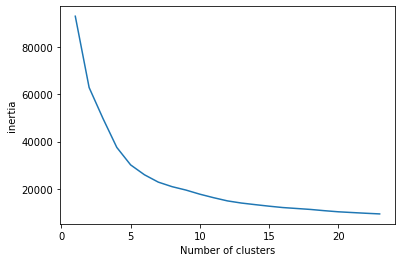

In [143]:
# Kmeans
from sklearn.cluster import KMeans

n_cat = hbp_data['bigcat'].nunique()

inertia = []
for i in range(1, n_cat):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(hbp_data[[str(i) for i in range(0,3)]])
    inertia.append(kmeans.inertia_)

plt.plot(range(1, n_cat), inertia)
plt.xlabel('Number of clusters')
plt.ylabel('inertia') 
plt.show()


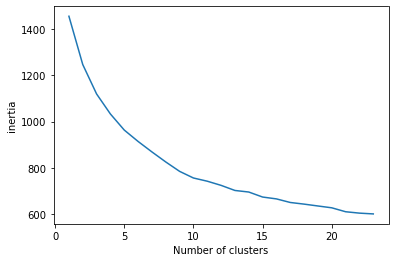

In [144]:
n_cat = eu_data['bigcat'].nunique()

inertia = []
for i in range(1, n_cat):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(eu_data[[str(i) for i in range(0,16)]])
    inertia.append(kmeans.inertia_)

plt.plot(range(1, n_cat), inertia)
plt.xlabel('Number of clusters')
plt.ylabel('inertia') 
plt.show()


In [145]:
from hyperbolicMDS.mds import cart_to_polar, poincare_dist_vec

def get_poincare_dist(group):
    """
    Getting the hyperbolic distance between the "root" of a category and each concept in this category
    Root = the concept in a category that is closest to the origin of the hyperbolic space
    """
    sort_group = group.sort_values(by='radius')
    sort_group['poincare_r'] = poincare_dist_vec(sort_group[[0,1,2]].values)[0]
    return sort_group

In [146]:
from scipy.optimize import minimize

def hyperbolic_centroid(points):

    def objective(x):
        # Candidate centroid + category points
        all_points = np.vstack([x, points])

        # Hyperbolic pairwise distances
        D = poincare_dist_vec(all_points)

        # Distances from candidate to category members
        d = D[0, 1:]

        # Fréchet objective
        return np.sum(d**2)

    # Initial guess
    x0 = points.mean(axis=0)
    result = minimize(objective, x0, method="BFGS", options={'gtol': 1e-3})

    if not result.success:
        print(result.message)

    return result.x

In [147]:
# agglomerative
from sklearn.cluster import AgglomerativeClustering

# 1. Find centroids of each category, using hbp distance
category_centroids = {}
for cat in hbp_data['cat_name'].unique():
    points = hbp_data[hbp_data['cat_name'] == cat][['0','1','2']]
    category_centroids[cat] = hyperbolic_centroid(points)
    # category_centroids[cat] = points.mean(axis=0)

category_centroids

Desired error not necessarily achieved due to precision loss.
Desired error not necessarily achieved due to precision loss.
Desired error not necessarily achieved due to precision loss.
Desired error not necessarily achieved due to precision loss.
Desired error not necessarily achieved due to precision loss.
Desired error not necessarily achieved due to precision loss.
Desired error not necessarily achieved due to precision loss.
Desired error not necessarily achieved due to precision loss.
Desired error not necessarily achieved due to precision loss.
Desired error not necessarily achieved due to precision loss.
Desired error not necessarily achieved due to precision loss.


{'animal': array([-2.25912354,  1.47211094, -1.50546837]),
 'home decor': array([-2.68619996,  1.38306396, -0.29735116]),
 'musical instrument': array([-2.67357447,  1.62289593,  0.38258415]),
 'other': array([-2.46813851,  1.40689516, -0.23132417]),
 'electronic device': array([-2.46207141,  1.30835542, -0.26180561]),
 'furniture': array([-2.73309314,  1.71401086, -0.42039227]),
 'tool': array([-2.53364586,  1.58440221,  0.36397437]),
 'part of car': array([-2.51514272,  1.47399134, -0.11962691]),
 'vehicle': array([-2.8118637 ,  1.75609004, -0.31239985]),
 'food': array([-2.94285742,  0.64456788, -0.41609836]),
 'plant': array([-3.27984923,  1.71098809, -0.84260802]),
 'body part': array([-2.01253849,  2.49832125, -0.48429881]),
 'clothing': array([-2.17825399,  2.3245271 , -0.23749473]),
 'container': array([-2.588094  ,  1.29740663, -0.45175288]),
 'weapon': array([-2.43518644,  1.59705257,  0.42272677]),
 'dessert': array([-3.10565547,  0.55653768, -0.30463757]),
 'sports equipmen

In [148]:
# 2. Dissimilarity matrix among category centroids
cat_rdm = poincare_dist_vec(np.array(pd.DataFrame(category_centroids.values())))
cat_rdm


array([[0.00000000e+00, 3.08788797e+00, 3.93631570e+00, 2.96066630e+00,
        2.88575260e+00, 3.09812886e+00, 3.79804627e+00, 3.17441773e+00,
        3.33312973e+00, 3.41469021e+00, 3.18041877e+00, 3.46012258e+00,
        3.51037403e+00, 2.75931944e+00, 3.79863383e+00, 3.73068082e+00,
        3.42481885e+00, 3.18268063e+00, 3.15620926e+00, 3.46419590e+00,
        3.30060057e+00, 2.88081085e+00, 3.77290431e+00, 3.32281914e+00],
       [3.08788797e+00, 0.00000000e+00, 2.11709949e+00, 4.66009445e-01,
        2.66883597e-01, 1.01791471e+00, 2.03172851e+00, 7.62509491e-01,
        9.94237732e-01, 2.22318017e+00, 1.80722070e+00, 3.21119116e+00,
        2.80993536e+00, 5.70141134e-01, 2.16275614e+00, 2.54362805e+00,
        1.59459297e+00, 1.17701046e+00, 1.85282758e+00, 1.98725614e+00,
        1.62327316e+00, 2.78448911e-01, 1.78532616e+00, 1.07292437e+00],
       [3.93631570e+00, 2.11709949e+00, 0.00000000e+00, 1.81274050e+00,
        1.90145832e+00, 2.43494991e+00, 2.00523665e-01, 1.5493

In [149]:
# 3. Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

np.fill_diagonal(cat_rdm, 0)
results = []

for k in range(2, 11):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="average", 
        metric="precomputed"
    )
    labels = model.fit_predict(cat_rdm)

    sil = silhouette_score(
        cat_rdm,
        labels,
        metric="precomputed", 
        random_state=42
    )

    results.append((k, sil))

results

[(2, 0.3868994997451332),
 (3, 0.3730427570480985),
 (4, 0.3928138527342308),
 (5, 0.3477316509727671),
 (6, 0.38093093294210156),
 (7, 0.3703409992406657),
 (8, 0.3623410710757007),
 (9, 0.3504322620262374),
 (10, 0.3001821221224997)]

In [150]:
import scipy.cluster.hierarchy as shc

k = 4
model = AgglomerativeClustering(
        n_clusters=k,
        linkage="average", 
        metric="precomputed"
    )
labels = model.fit_predict(cat_rdm)
labels


array([3, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 2, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0])

In [151]:
cat_centroids = pd.DataFrame(list(category_centroids.values()))
cat_centroids['cat_name'] = category_centroids.keys()
cat_centroids['group'] = labels
cat_centroids

,0,1,2,cat_name,group
0,-2.259124,1.472111,-1.505468,animal,3
1,-2.686200,1.383064,-0.297351,home decor,0
2,-2.673574,1.622896,0.382584,musical instrument,0
3,-2.468139,1.406895,-0.231324,other,0
4,-2.462071,1.308355,-0.261806,electronic device,0
5,-2.733093,1.714011,-0.420392,furniture,0
6,-2.533646,1.584402,0.363974,tool,0
7,-2.515143,1.473991,-0.119627,part of car,0
8,-2.811864,1.756090,-0.312400,vehicle,0
9,-2.942857,0.644568,-0.416098,food,1


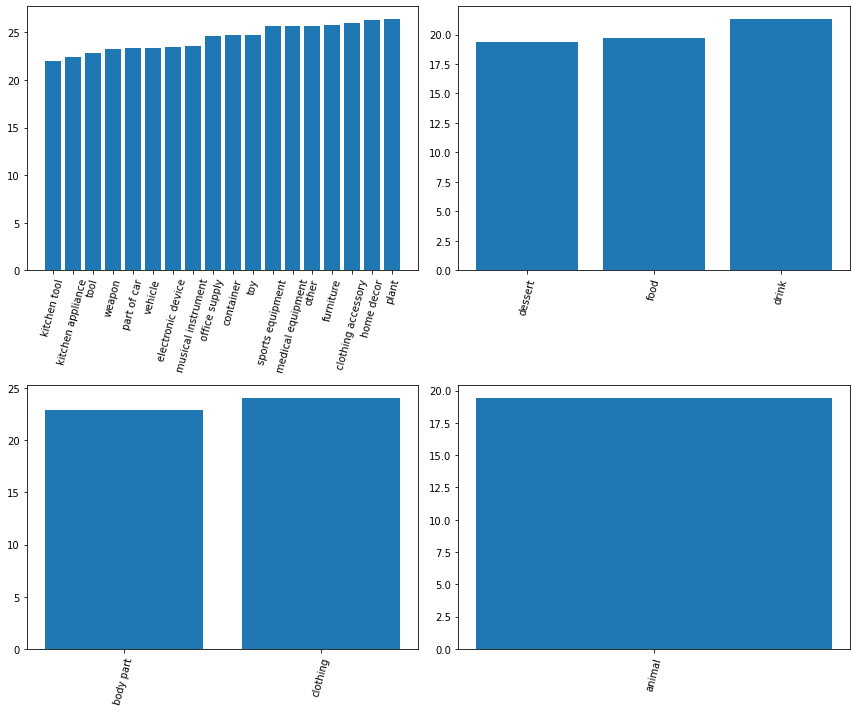

In [152]:
# 4. Radial: within each cluster, plot the radius of each category centroid
# cat_centroids['radius'] = np.sqrt((cat_centroids[[0,1,2]]**2).sum(axis=1))
cat_radius = hbp_data.groupby(['cat_name'])['radius'].mean().reset_index()
cat_centroids = cat_centroids.merge(cat_radius, how='inner', on='cat_name')
cat_centroids = cat_centroids.sort_values(by='radius')

fig, ([ax1, ax2], [ax3, ax4]) = plt.subplots(2, 2, figsize=(12, 10))
ax = [ax1, ax2, ax3, ax4]

for i in range(0,k):
    cat = cat_centroids[cat_centroids['group'] == i]
    ax[i].bar(cat['cat_name'], cat['radius'])
    ax[i].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

<Figure size 432x288 with 0 Axes>

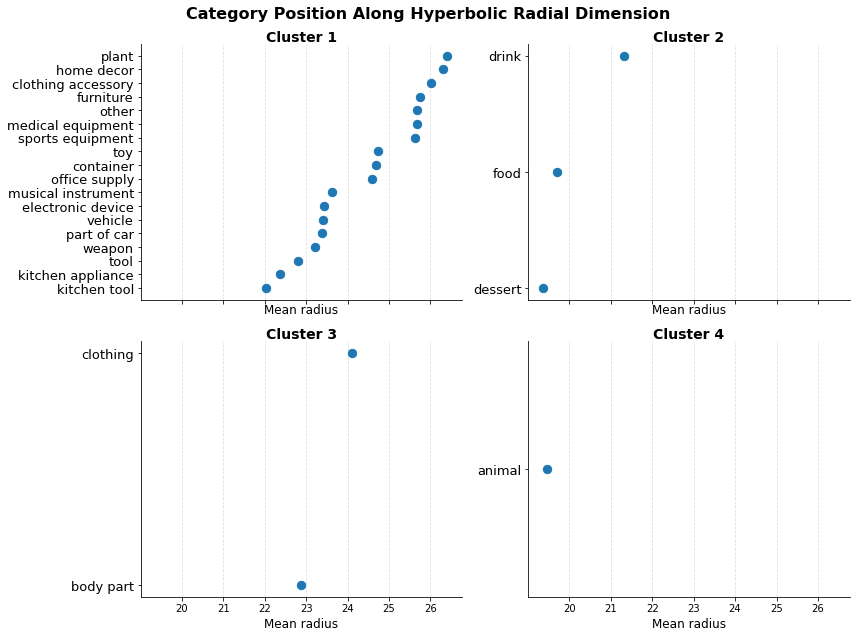

In [153]:
plt.clf()
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True
)

axes = axes.flatten()

for i in range(k):
    ax = axes[i]

    cat = (
        cat_centroids[cat_centroids['group'] == i]
        .sort_values('radius')
    )

    y = range(len(cat))

    ax.scatter(
        cat['radius'],
        y,
        s=70,
        zorder=3
    )

    ax.set_yticks(y)
    ax.set_yticklabels(cat['cat_name'], fontsize=13)

    ax.set_title(
        f'Cluster {i + 1}',
        fontsize=14,
        fontweight='bold',
        pad=3
    )

    ax.set_xlabel('Mean radius', fontsize=12)
    ax.grid(
        axis='x',
        linestyle='--',
        alpha=0.4
    )
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for i in range(k, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    'Category Position Along Hyperbolic Radial Dimension',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('../outputs/hbp_grouping.pdf')

plt.show()


In [154]:
# number of concepts in category is correlated with radius of category? Nope
concept_per_cat = hbp_data.groupby('cat_name')['radius'].count().reset_index().rename(columns={'radius': 'n_concepts'})
cat_centroids = cat_centroids.merge(concept_per_cat, how='inner', on='cat_name')
stats.spearmanr(cat_centroids['n_concepts'], cat_centroids['radius'])

SignificanceResult(statistic=-0.10402617692872847, pvalue=0.6285756686930131)

In [155]:
# eu space: no meaningful clustering
eu_matrix = np.array(eu_data.groupby('bigcat').mean().iloc[:, 1:17])
eu_rdm = abs(np.corrcoef(eu_matrix))
eu_rdm = (1-abs(eu_rdm.T + eu_rdm)/2)
np.fill_diagonal(eu_rdm, 0)

results = []

for k in range(2, 15):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="average", 
        metric="precomputed"
    )
    labels = model.fit_predict(eu_rdm)

    sil = silhouette_score(
        eu_rdm,
        labels,
        metric="precomputed", 
        random_state=42
    )

    results.append((k, sil))

results

[(2, 0.4189627581423696),
 (3, 0.30189990079066537),
 (4, 0.3177377293602757),
 (5, 0.2759024696285316),
 (6, 0.24620454253387028),
 (7, 0.24926613011860618),
 (8, 0.30117369559352813),
 (9, 0.32868809823820755),
 (10, 0.3244368069878582),
 (11, 0.2827469964943483),
 (12, 0.2583575245618002),
 (13, 0.30641613049730915),
 (14, 0.2911155718446287)]

In [156]:
# 
k = 4
model = AgglomerativeClustering(
        n_clusters=k,
        linkage="average", 
        metric="precomputed"
    )
labels = model.fit_predict(eu_rdm)
labels

array([0, 3, 3, 3, 0, 1, 1, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0])

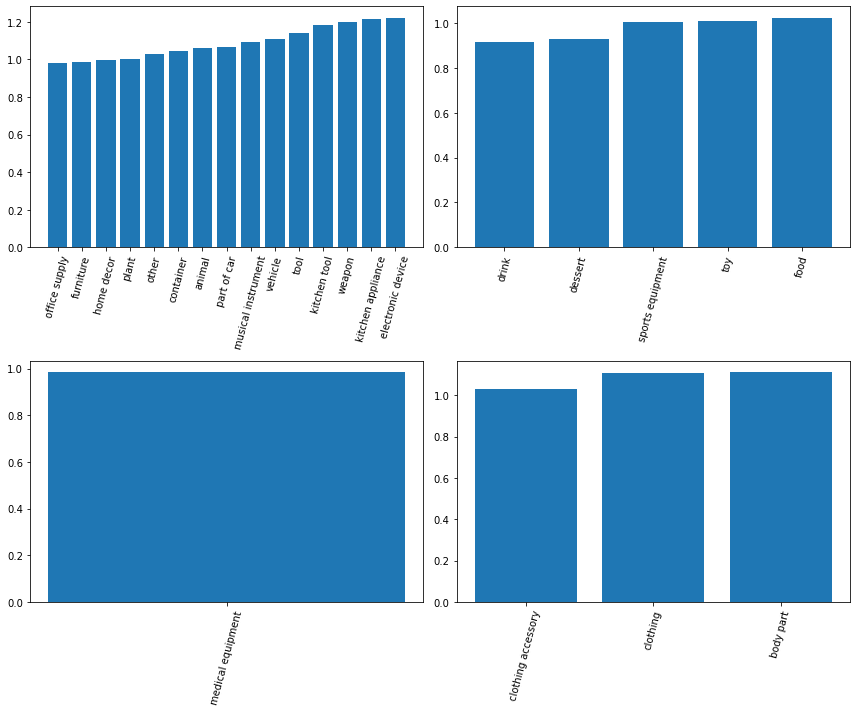

In [157]:
eu_group = eu_data[['bigcat', 'cat_name', 'radius']].groupby('bigcat').agg({'cat_name':'first', 'radius':'mean'}).reset_index()
eu_group['group'] = labels
eu_group = pd.concat([eu_group, pd.DataFrame(eu_matrix)], axis=1)
# eu_group['radius'] = np.sqrt((eu_group.loc[:, 0:15]**2).sum(axis=1))
eu_group = eu_group.sort_values(by='radius')
eu_group.loc[23, 'cat_name'] = 'other'

fig, ([ax1, ax2], [ax3, ax4]) = plt.subplots(2, 2, figsize=(12, 10))
ax = [ax1, ax2, ax3, ax4]

for i in range(0,k):
    cat = eu_group[eu_group['group'] == i]
    ax[i].bar(cat['cat_name'], cat['radius'])
    ax[i].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()


<Figure size 432x288 with 0 Axes>

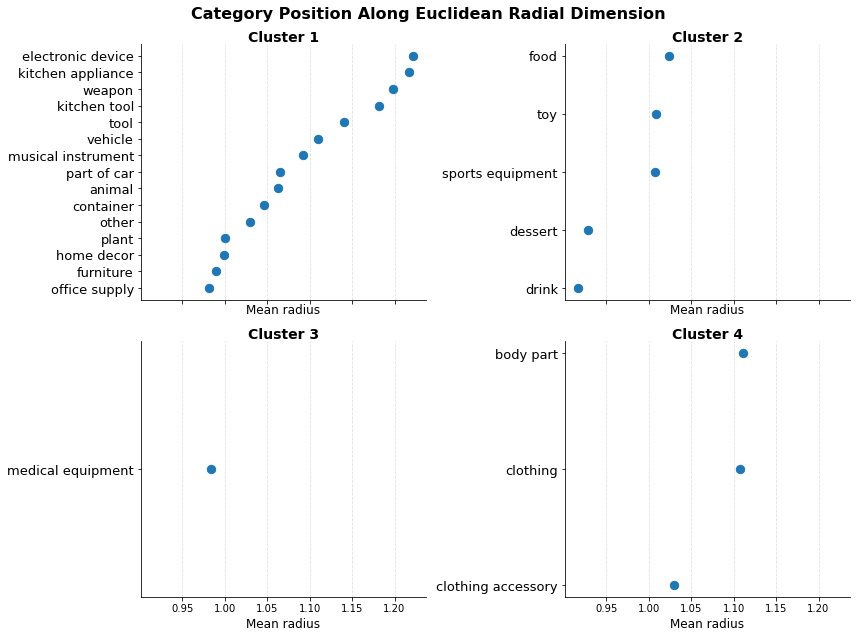

In [158]:
plt.clf()
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True
)

axes = axes.flatten()

for i in range(k):
    ax = axes[i]

    cat = (
        eu_group[eu_group['group'] == i]
        .sort_values('radius')
    )

    y = range(len(cat))

    ax.scatter(
        cat['radius'],
        y,
        s=70,
        zorder=3
    )

    ax.set_yticks(y)
    ax.set_yticklabels(cat['cat_name'], fontsize=13)

    ax.set_title(
        f'Cluster {i + 1}',
        fontsize=14,
        fontweight='bold',
        pad=3
    )

    ax.set_xlabel('Mean radius', fontsize=12)
    ax.grid(
        axis='x',
        linestyle='--',
        alpha=0.4
    )
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for i in range(k, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    'Category Position Along Euclidean Radial Dimension',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('../outputs/eu_grouping.pdf')

plt.show()


# 66-dimensional dataset

In [159]:
feature_embeddings_66 = np.load('../albatross_66/outputs/membatross_embeddings_66_0.npy')

for i in range(1, 4):
    feature_embeddings_66 = np.dstack((feature_embeddings_66, np.load(f'../albatross_66/outputs/membatross_embeddings_66_{i}.npy')))
feature_embeddings_66.shape

(66, 3, 500)

In [160]:
# np.save('../albatross_66/outputs/membatross_embeddings_66.npy', feature_embeddings_66)
np.load('../albatross_66/outputs/membatross_embeddings_66.npy').shape

(66, 3, 500)

In [161]:
### normalize embeddings and transform concept embeddings to loadings in hyperbolic feature space
original_embeddings_66 = np.loadtxt(os.path.join(data_dir, 'spose_embedding_66d_sorted.txt'))
print(original_embeddings_66.shape)

concept_in_feat_coord = []
normalized_embeddings = (original_embeddings_66.T/np.sqrt((original_embeddings_66**2).sum(axis=1))).T
for layer in range(feature_embeddings_66.shape[-1]):
    concept_in_feat_coord.append(normalized_embeddings@feature_embeddings_66[:,:,layer])
np.array(concept_in_feat_coord).shape

(1854, 66)


(500, 1854, 3)

In [162]:
### procrustes of concept loadings in hyperbolic feature space
from scipy.linalg import orthogonal_procrustes

concept_in_feat_reference = concept_in_feat_coord[0]
concept_in_feat_output = [concept_in_feat_reference]
for i in range(1, len(concept_in_feat_coord)):
    R, scale = orthogonal_procrustes(concept_in_feat_coord[i], concept_in_feat_reference)
    concept_in_feat_output.append(concept_in_feat_coord[i]@R)
concept_in_feat_reference

array([[-10.92409652,  14.87008739,   0.44617579],
       [-11.79377267,   3.40042073,   4.05083098],
       [ -1.39212465,   3.85925945,   4.24973215],
       ...,
       [-10.65435237,  11.87351228,  -2.03547246],
       [ -5.19636923,   0.29661466,   3.61330508],
       [-18.20859   ,  -2.51404159,   8.70404557]])

In [164]:
### procrustes of feature embeddings
feature_embed_reference = feature_embeddings_66[:,:,0]
feature_embed_output = [feature_embed_reference]
for i in range(1, feature_embeddings_66.shape[-1]):
    R, scale = orthogonal_procrustes(feature_embeddings_66[:,:,i], feature_embed_reference)
    feature_embed_output.append(feature_embeddings_66[:,:,i]@R)

In [165]:
### average across 500 layers
mean_concept_in_feat = np.array(concept_in_feat_output).mean(axis=0)
mean_feature_embed = np.array(feature_embed_output).mean(0)

In [166]:
# % of space taken up by features

### Get the range of features in hyperbolic space
r_feat, r_phi, r_theta = cart_to_polar(mean_feature_embed).T
maxtheta = max(r_theta)
mintheta = min(r_theta)
maxphi = max(r_phi)
minphi = min(r_phi)
pi = np.pi
print(maxtheta, mintheta, maxphi, minphi)
print(maxtheta/pi, mintheta/pi, maxphi/pi, minphi/pi)

### Get the proportion of space that features take up
(2/3*(maxtheta-mintheta)*(maxphi-minphi)/pi*(18**3-7.2**3))/(4*pi/3*(18**3-7.2**3))

6.236915848816698 0.11015596227877042 2.897239171629957 0.02011329562381447
1.9852719739747233 0.03506373181542135 0.9222198709687516 0.006402260840797319


0.8930175257930851

In [391]:
# load categories and memorability score of each concept
cat_mapping = pd.read_csv(os.path.join(data_dir, 'THINGS_Table.csv'))
cat_concept_mem = cat_mapping[['cr', 'smallcat', 'bigcat']].groupby('smallcat').mean()
cat_concept_mem['bigcat'] = cat_concept_mem['bigcat'].astype(int).replace(0, 99)

### load category names and merge with concepts
cat = loadmat(os.path.join(data_dir,'categories.mat'))
cat_names = [item[0] for item in cat['categories'][0]]
cat_names.append('na')
cat_names = pd.DataFrame(cat_names, columns=['cat_name']).reset_index()
cat_names['index'] = cat_names['index']+1
cat_names.iloc[27] = [99, np.nan]
cat_concept_mem = cat_concept_mem.merge(cat_names, how='left', left_on='bigcat', right_on='index').drop(columns=['index'])
cat_concept_mem


,cr,bigcat,cat_name
0,0.779739,1,animal
1,0.798485,13,home decor
2,0.752845,18,musical instrument
3,0.761851,99,NaN
4,0.794466,9,electronic device
...,...,...,...
1849,0.722655,99,NaN
1850,0.843158,10,food
1851,0.800163,1,animal
1852,0.797468,99,NaN


In [412]:
### merge concept loadings with category and memorability
mean_concept_in_feat_cat = pd.DataFrame(mean_concept_in_feat).merge(cat_concept_mem, how='left', left_index=True, right_index=True)
mean_concept_in_feat_cat

,0,1,2,cr,bigcat,cat_name
0,-6.778399,10.340897,1.114734,0.779739,1,animal
1,-13.614493,3.546045,3.544124,0.798485,13,home decor
2,-10.409975,2.851230,3.106945,0.752845,18,musical instrument
3,-12.050159,7.185565,3.170662,0.761851,99,NaN
4,-9.545562,7.766997,4.108522,0.794466,9,electronic device
...,...,...,...,...,...,...
1849,-13.817713,8.770525,3.177602,0.722655,99,NaN
1850,-8.339277,6.398025,8.857011,0.843158,10,food
1851,-6.207225,8.302914,0.353662,0.800163,1,animal
1852,-8.591653,5.109321,3.018425,0.797468,99,NaN


In [ ]:
# mean_concept_in_feat_cat.to_csv('./data/concept_embeddings_cr_cat_66_3hbp.csv')
pd.read_csv('./data/concept_embeddings_cr_cat_66_3hbp.csv')

,Unnamed: 0,0,1,2,cr,bigcat,cat_name
0,0,-6.778399,10.340897,1.114734,0.779739,1,animal
1,1,-13.614493,3.546045,3.544124,0.798485,13,home decor
2,2,-10.409975,2.851230,3.106945,0.752845,18,musical instrument
3,3,-12.050159,7.185565,3.170662,0.761851,99,NaN
4,4,-9.545562,7.766997,4.108522,0.794466,9,electronic device
...,...,...,...,...,...,...,...
1849,1849,-13.817713,8.770525,3.177602,0.722655,99,NaN
1850,1850,-8.339277,6.398025,8.857011,0.843158,10,food
1851,1851,-6.207225,8.302914,0.353662,0.800163,1,animal
1852,1852,-8.591653,5.109321,3.018425,0.797468,99,NaN


In [442]:
# 13D eu space
from sklearn.manifold import MDS
from scipy.spatial import distance_matrix

np.random.seed(0)

input_distance_matrix = pd.read_csv('../data/coef_embed_66.csv', header=None).to_numpy()

### Multi-dimensional scaling
embedding = MDS(n_components=13, random_state=42, dissimilarity='precomputed')
transformed_dist = embedding.fit_transform(input_distance_matrix)
# np.save(os.path.join(data_dir, 'feature_embeddings_16deu.npy'), transformed_dist)

eu_dist = distance_matrix(transformed_dist, transformed_dist)
stats.spearmanr(eu_dist.flatten(),input_distance_matrix.flatten()) 

SignificanceResult(statistic=0.5796592544626759, pvalue=0.0)

In [443]:
### normalize embeddings and transform concept embeddings to loadings in feature space
normalized_embeddings = (original_embeddings_66.T/np.sqrt((original_embeddings_66**2).sum(axis=1))).T
concept_in_feat_coord = normalized_embeddings@transformed_dist
np.array(concept_in_feat_coord).shape

(1854, 13)

In [ ]:
# % of space in 13d eu - bounding sphere
# Calculate radial distance (l2 norm) from origin for each data point
radii = np.linalg.norm(normalized_embeddings, axis=1)

r_data_max = np.max(radii)
r_data_min = np.min(radii)  # If using a spherical shell [r_min, r_max]

# Define reference outer radius (e.g., maximum possible embedding radius or 1.0)
r_ref = np.sqrt(13 * (1.0 ** 2))

# Volume of a 16D ball formula
def volume_13d_ball(r):
    return (np.pi**(13/2) / gamma(13/2+1)) * (r**13)

# Volume occupied by data (solid hyperball vs shell)
vol_data_ball = volume_13d_ball(r_data_max)
vol_data_shell = volume_13d_ball(r_data_max) - volume_13d_ball(r_data_min)
vol_ref_ball = volume_13d_ball(r_ref)

prop_hyperball = vol_data_ball / vol_ref_ball
prop_hypershell = vol_data_shell / vol_ref_ball

print(f"Max Data Radius: {r_data_max:.4f}")
print(f"Hyperball Volume Proportion: {prop_hyperball:.6e}")
print(f"Hypershell Volume Proportion: {prop_hypershell:.6e}")

Max Data Radius: 1.0000
Hyperball Volume Proportion: 5.746034e-08
Hypershell Volume Proportion: 4.203280e-22


In [171]:
# % of space in 13 eu - bounding box
# 1. Compute min and max along each of the 13 dimensions
min_coords = normalized_embeddings.min(axis=0)
max_coords = normalized_embeddings.max(axis=0)

# 2. Compute the side lengths (ranges) of the 13D bounding hyperrectangle
side_lengths = max_coords - min_coords

# 3. Volume of the 13D bounding box containing your data
#    In N dimensions, volume = product of all side lengths
data_volume = np.prod(side_lengths)

# 4. Define the reference domain volume:

# Reference domain defined by feature bounds / normalization (e.g., [-1, 1] per dimension)
ref_min = -1.0  # replace with your actual space bounds min
ref_max = 1.0   # replace with your actual space bounds max
ref_side_length = ref_max - ref_min
total_reference_volume = ref_side_length ** 13

# 5. Calculate proportion of space occupied
proportion_occupied = data_volume / total_reference_volume

print(f"16D Data Bounding Box Volume: {data_volume:.6e}")
print(f"Total Reference Volume:       {total_reference_volume:.6e}")
print(f"Proportion of Space Occupied: {proportion_occupied:.6e}")

16D Data Bounding Box Volume: 5.507262e-12
Total Reference Volume:       8.192000e+03
Proportion of Space Occupied: 6.722733e-16


In [448]:
### merge concept loadings with category and memorability
mean_concept_in_feat_cat_eu = pd.DataFrame(concept_in_feat_coord).merge(cat_concept_mem, how='left', left_index=True, right_index=True)
mean_concept_in_feat_cat_eu

,0,1,2,3,4,5,6,7,8,9,10,11,12,cr,bigcat,cat_name
0,0.173735,-0.118949,0.018561,-0.043642,-0.098520,-0.017052,-0.231767,0.088793,-0.010209,-0.152849,0.154161,-0.059065,-0.079703,0.779739,1,animal
1,0.081920,0.000922,0.240567,-0.014998,-0.088131,0.385645,-0.200526,0.172358,-0.362197,-0.075362,0.133649,-0.201809,-0.171382,0.798485,13,home decor
2,0.014394,0.194592,0.150479,-0.063404,-0.072999,0.410960,-0.222403,0.037911,-0.302047,-0.017895,0.266767,-0.206276,-0.045737,0.752845,18,musical instrument
3,0.097034,-0.156142,0.198237,0.303425,-0.074207,0.281573,-0.185217,0.167355,0.116382,-0.100895,0.322119,-0.124267,0.099626,0.761851,99,NaN
4,-0.068054,-0.042979,-0.091058,0.213735,-0.249347,-0.077225,-0.218620,0.143488,-0.124492,-0.012096,0.194170,-0.025409,-0.318355,0.794466,9,electronic device
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,0.197066,-0.245800,0.089268,0.126652,0.042927,0.039848,0.074163,0.347982,-0.122499,-0.083958,0.089709,-0.209900,-0.142594,0.722655,99,NaN
1850,0.120902,-0.175879,0.300354,0.351545,-0.072641,0.082736,-0.029463,0.004319,-0.019616,-0.303770,0.115645,0.091122,0.016842,0.843158,10,food
1851,0.181345,-0.032844,-0.002106,-0.125590,-0.120786,0.074423,-0.299202,-0.055413,-0.148794,-0.135293,0.186621,-0.094514,-0.251467,0.800163,1,animal
1852,0.016824,-0.035908,-0.091544,0.154780,-0.057087,0.153399,-0.050873,-0.022305,-0.249758,-0.039849,0.309730,0.109741,-0.046064,0.797468,99,NaN


In [ ]:
# mean_concept_in_feat_cat_eu.to_csv('./data/concept_embeddings_cr_cat_66_13eu.csv')
pd.read_csv('./data/concept_embeddings_cr_cat_66_13eu.csv')

,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,11,12,cr,bigcat,cat_name
0,0,0.173735,-0.118949,0.018561,-0.043642,-0.098520,-0.017052,-0.231767,0.088793,-0.010209,-0.152849,0.154161,-0.059065,-0.079703,0.779739,1,animal
1,1,0.081920,0.000922,0.240567,-0.014998,-0.088131,0.385645,-0.200526,0.172358,-0.362197,-0.075362,0.133649,-0.201809,-0.171382,0.798485,13,home decor
2,2,0.014394,0.194592,0.150479,-0.063404,-0.072999,0.410960,-0.222403,0.037911,-0.302047,-0.017895,0.266767,-0.206276,-0.045737,0.752845,18,musical instrument
3,3,0.097034,-0.156142,0.198237,0.303425,-0.074207,0.281573,-0.185217,0.167355,0.116382,-0.100895,0.322119,-0.124267,0.099626,0.761851,99,NaN
4,4,-0.068054,-0.042979,-0.091058,0.213735,-0.249347,-0.077225,-0.218620,0.143488,-0.124492,-0.012096,0.194170,-0.025409,-0.318355,0.794466,9,electronic device
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1849,0.197066,-0.245800,0.089268,0.126652,0.042927,0.039848,0.074163,0.347982,-0.122499,-0.083958,0.089709,-0.209900,-0.142594,0.722655,99,NaN
1850,1850,0.120902,-0.175879,0.300354,0.351545,-0.072641,0.082736,-0.029463,0.004319,-0.019616,-0.303770,0.115645,0.091122,0.016842,0.843158,10,food
1851,1851,0.181345,-0.032844,-0.002106,-0.125590,-0.120786,0.074423,-0.299202,-0.055413,-0.148794,-0.135293,0.186621,-0.094514,-0.251467,0.800163,1,animal
1852,1852,0.016824,-0.035908,-0.091544,0.154780,-0.057087,0.153399,-0.050873,-0.022305,-0.249758,-0.039849,0.309730,0.109741,-0.046064,0.797468,99,NaN


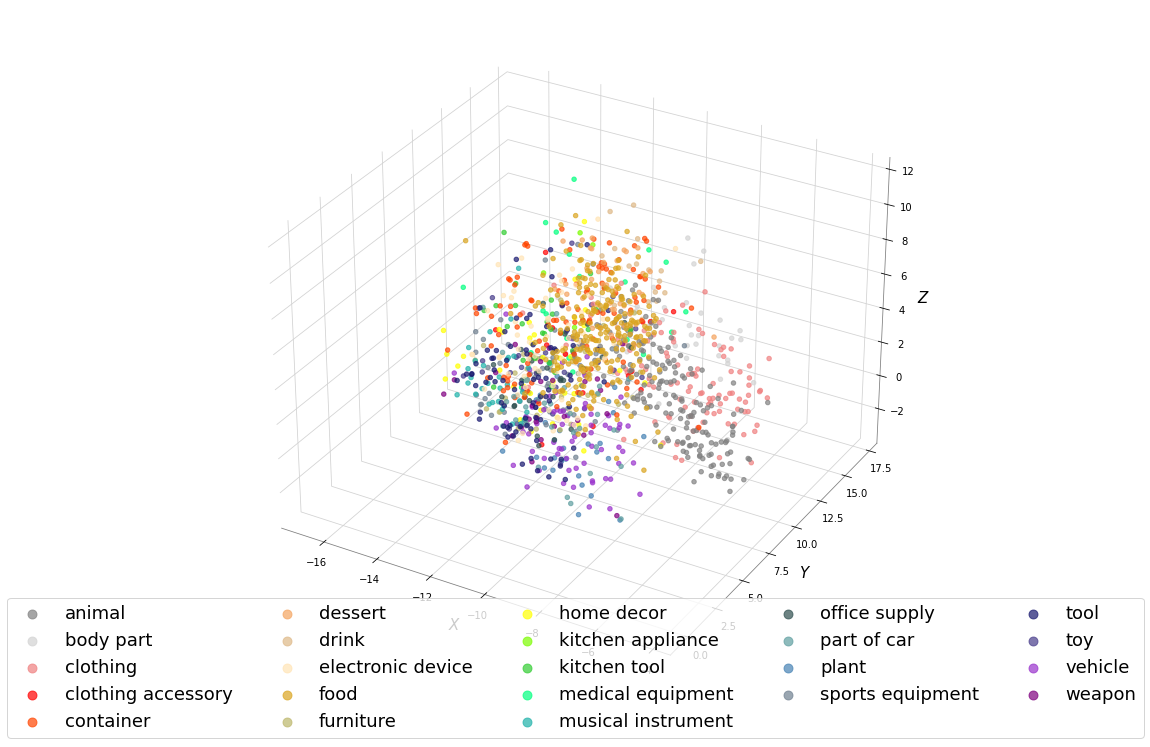

In [397]:
### color-coding categories
import matplotlib.colors as mcolors
%matplotlib inline

colors = mcolors.CSS4_COLORS
by_hsv = sorted((tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(color))), name)
                for name, color in colors.items())
color_names = [name for hsv, name in by_hsv]

fig, ax1 = plt.subplots(1, 1, figsize=(17, 11), subplot_kw={'projection': '3d'})
# ax = fig.add_subplot(projection='3d')

# Set background color of the 3D plot area
ax1.set_facecolor('white') 

# Set grid color to grey
ax1.xaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')
ax1.yaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')
ax1.zaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')

ax1.w_xaxis.line.set_color("grey")
ax1.w_yaxis.line.set_color("grey")
ax1.w_zaxis.line.set_color("grey")

# Set background color to white
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False

ax1.xaxis.pane.set_edgecolor('w')
ax1.yaxis.pane.set_edgecolor('w')
ax1.zaxis.pane.set_edgecolor('w')

groups = mean_concept_in_feat_cat.groupby("cat_name")
i = 3
for name, group in groups:
    ax1.scatter(group[0], group[1], group[2], label=name, alpha=0.7, color=color_names[i])
    i = i+6
fig.legend(loc='lower center', ncol=5, facecolor='white',fontsize=18, markerscale=2)
ax1.set_xlabel('$X$', fontsize=15)
ax1.set_ylabel('$Y$', fontsize=15)
ax1.set_zlabel('$Z$', fontsize=15)

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.tight_layout(pad=5)

# plt.savefig('../outputs/categories_hbp_eu.pdf')
# ax.scatter(mean_feature_embed.T[0], mean_feature_embed.T[1], mean_feature_embed.T[2], color='red')


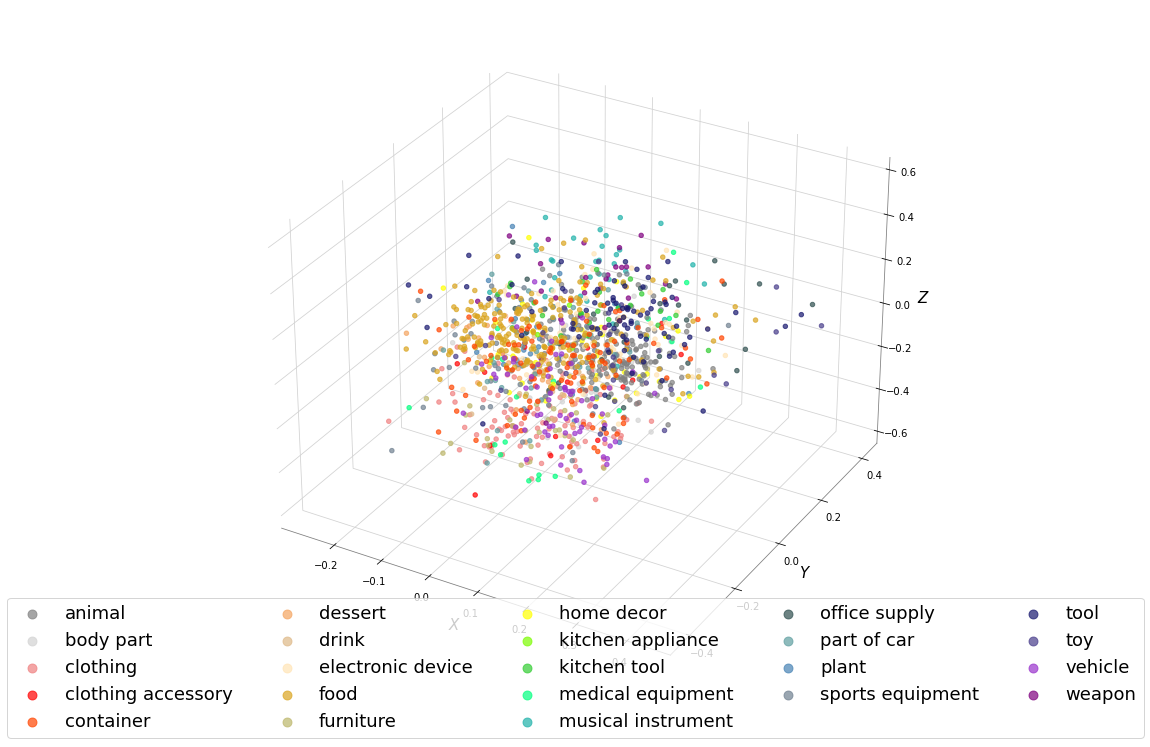

In [450]:
### color-coding categories - 13eu
import matplotlib.colors as mcolors
%matplotlib inline

colors = mcolors.CSS4_COLORS
by_hsv = sorted((tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(color))), name)
                for name, color in colors.items())
color_names = [name for hsv, name in by_hsv]

fig, ax1 = plt.subplots(1, 1, figsize=(17, 11), subplot_kw={'projection': '3d'})
# ax = fig.add_subplot(projection='3d')

# Set background color of the 3D plot area
ax1.set_facecolor('white') 

# Set grid color to grey
ax1.xaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')
ax1.yaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')
ax1.zaxis._axinfo['grid'].update(color = 'lightgrey', linestyle = '-')

ax1.w_xaxis.line.set_color("grey")
ax1.w_yaxis.line.set_color("grey")
ax1.w_zaxis.line.set_color("grey")

# Set background color to white
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False

ax1.xaxis.pane.set_edgecolor('w')
ax1.yaxis.pane.set_edgecolor('w')
ax1.zaxis.pane.set_edgecolor('w')

groups = mean_concept_in_feat_cat_eu.groupby("cat_name")
i = 3
for name, group in groups:
    ax1.scatter(group[0], group[1], group[2], label=name, alpha=0.7, color=color_names[i])
    i = i+6
fig.legend(loc='lower center', ncol=5, facecolor='white',fontsize=18, markerscale=2)
ax1.set_xlabel('$X$', fontsize=15)
ax1.set_ylabel('$Y$', fontsize=15)
ax1.set_zlabel('$Z$', fontsize=15)

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.tight_layout(pad=5)

# plt.savefig('../outputs/categories_hbp_eu.pdf')
# ax.scatter(mean_feature_embed.T[0], mean_feature_embed.T[1], mean_feature_embed.T[2], color='red')


In [ ]:
# typicality
hbp_66 = pd.read_csv('./figures_v2/hbp_66/hbp_data.csv', index_col=0)
hbp_66

,Unnamed: 0.1,0,1,2,cr,bigcat,cat_name,human_typ,radius,within_cat_distance_raw,within_cat_distance,between_cat_distance,between_cat_distance_eu,between_cat_distance_resid
0,0,-6.778399,10.340897,1.114734,0.779739,1,animal,4.874352,12.414648,-1.276657,-1.276657,23.154477,928.672834,0.466290
1,1,-13.614493,3.546045,3.544124,0.798485,13,home decor,6.374555,14.508263,0.993466,0.993466,24.840173,927.858927,0.193105
2,2,-10.409975,2.851230,3.106945,0.752845,18,musical instrument,5.342846,11.231660,-2.640486,-2.640486,21.543660,925.499673,-0.037671
3,3,-12.050159,7.185565,3.170662,0.761851,99,other,4.655669,14.383733,-0.488019,-0.488019,23.952049,908.937387,-0.578503
4,4,-9.545562,7.766997,4.108522,0.794466,9,electronic device,5.288886,12.973972,-0.375689,-0.375689,22.632016,921.569698,-0.579500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1849,-13.817713,8.770525,3.177602,0.722655,99,other,NaN,16.671787,1.837188,1.837188,26.248890,937.192473,-0.422469
1850,1850,-8.339277,6.398025,8.857011,0.843158,10,food,NaN,13.744995,0.715057,0.715057,24.671206,916.968813,0.738286
1851,1851,-6.207225,8.302914,0.353662,0.800163,1,animal,NaN,10.372710,-3.807722,-3.807722,21.090990,922.463770,0.313331
1852,1852,-8.591653,5.109321,3.018425,0.797468,99,other,NaN,10.441866,-4.374200,-4.374200,19.986636,940.151387,-0.855728


In [421]:
# radius 
zscore_mem = stats.zscore(hbp_66['cr'])
concept_constant = sm.add_constant(stats.zscore(hbp_66[['radius']]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     9.424
Date:                Wed, 09 Sep 2026   Prob (F-statistic):            0.00217
Time:                        23:13:26   Log-Likelihood:                -2626.0
No. Observations:                1854   AIC:                             5256.
Df Residuals:                    1852   BIC:                             5267.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius         0.0712      0.023      3.070      0.0

In [425]:
# radius -> attraction
zscore_mem = stats.zscore(hbp_66[hbp_66['bigcat']!=99]['within_cat_distance'])
concept_constant = sm.add_constant(stats.zscore(hbp_66[hbp_66['bigcat']!=99][['radius']]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                             OLS Regression Results                            
Dep. Variable:     within_cat_distance   R-squared:                       0.732
Model:                             OLS   Adj. R-squared:                  0.732
Method:                  Least Squares   F-statistic:                     3619.
Date:                 Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                         23:14:27   Log-Likelihood:                -1005.9
No. Observations:                 1324   AIC:                             2016.
Df Residuals:                     1322   BIC:                             2026.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius         0.8558      0.014     60.16

In [426]:
# radius -> repulsion
zscore_mem = stats.zscore(hbp_66[hbp_66['bigcat']!=99]['between_cat_distance_resid'])
concept_constant = sm.add_constant(stats.zscore(hbp_66[hbp_66['bigcat']!=99][['radius']]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                                OLS Regression Results                                
Dep. Variable:     between_cat_distance_resid   R-squared:                       0.000
Model:                                    OLS   Adj. R-squared:                 -0.000
Method:                         Least Squares   F-statistic:                    0.5622
Date:                        Wed, 09 Sep 2026   Prob (F-statistic):              0.454
Time:                                23:14:51   Log-Likelihood:                -1878.4
No. Observations:                        1324   AIC:                             3761.
Df Residuals:                            1322   BIC:                             3771.
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [424]:
# 3 predictors
zscore_mem = stats.zscore(hbp_66[hbp_66['bigcat']!=99]['cr'])
concept_constant = sm.add_constant(stats.zscore(hbp_66[hbp_66['bigcat']!=99][['radius', 'within_cat_distance', 'between_cat_distance_resid']]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     39.11
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           3.25e-24
Time:                        23:14:12   Log-Likelihood:                -1822.3
No. Observations:                1324   AIC:                             3653.
Df Residuals:                    1320   BIC:                             3673.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
radius              

In [451]:
# typicality - eu
eu_66 = pd.read_csv('./figures_v2/hbp_66/eu_data.csv', index_col=0)
eu_66

,Unnamed: 0.1,0,1,2,3,4,5,6,7,8,...,11,12,cr,bigcat,cat_name,human_typ,radius,within_cat_distance,between_cat_distance,between_cat_distance_resid
0,0,0.173735,-0.118949,0.018561,-0.043642,-0.098520,-0.017052,-0.231767,0.088793,-0.010209,...,-0.059065,-0.079703,0.779739,1,animal,4.874352,0.418632,-0.138350,1.181085,0.047225
1,1,0.081920,0.000922,0.240567,-0.014998,-0.088131,0.385645,-0.200526,0.172358,-0.362197,...,-0.201809,-0.171382,0.798485,13,home decor,6.374555,0.718361,-0.093797,1.120043,-0.160554
2,2,0.014394,0.194592,0.150479,-0.063404,-0.072999,0.410960,-0.222403,0.037911,-0.302047,...,-0.206276,-0.045737,0.752845,18,musical instrument,5.342846,0.705134,0.013479,1.262936,-0.011185
3,3,0.097034,-0.156142,0.198237,0.303425,-0.074207,0.281573,-0.185217,0.167355,0.116382,...,-0.124267,0.099626,0.761851,99,NaN,4.655669,0.681994,-0.079634,1.135663,-0.127129
4,4,-0.068054,-0.042979,-0.091058,0.213735,-0.249347,-0.077225,-0.218620,0.143488,-0.124492,...,-0.025409,-0.318355,0.794466,9,electronic device,5.288886,0.593562,0.013629,1.202027,-0.017473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1849,0.197066,-0.245800,0.089268,0.126652,0.042927,0.039848,0.074163,0.347982,-0.122499,...,-0.209900,-0.142594,0.722655,99,NaN,NaN,0.589727,-0.081852,1.132672,-0.084950
1850,1850,0.120902,-0.175879,0.300354,0.351545,-0.072641,0.082736,-0.029463,0.004319,-0.019616,...,0.091122,0.016842,0.843158,10,food,NaN,0.622075,-0.091733,1.127115,-0.106343
1851,1851,0.181345,-0.032844,-0.002106,-0.125590,-0.120786,0.074423,-0.299202,-0.055413,-0.148794,...,-0.094514,-0.251467,0.800163,1,animal,NaN,0.556689,-0.025490,1.195054,-0.006394
1852,1852,0.016824,-0.035908,-0.091544,0.154780,-0.057087,0.153399,-0.050873,-0.022305,-0.249758,...,0.109741,-0.046064,0.797468,99,NaN,NaN,0.487699,-0.173561,0.984983,-0.182690


In [452]:
# radius 
zscore_mem = stats.zscore(eu_66['cr'])
concept_constant = sm.add_constant(stats.zscore(eu_66[['radius']]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     6.737
Date:                Wed, 09 Sep 2026   Prob (F-statistic):            0.00952
Time:                        23:53:15   Log-Likelihood:                -2627.3
No. Observations:                1854   AIC:                             5259.
Df Residuals:                    1852   BIC:                             5270.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius        -0.0602      0.023     -2.596      0.0

In [453]:
# radius -> attraction
zscore_mem = stats.zscore(eu_66[eu_66['bigcat']!=99]['within_cat_distance'])
concept_constant = sm.add_constant(stats.zscore(eu_66[eu_66['bigcat']!=99][['radius']]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                             OLS Regression Results                            
Dep. Variable:     within_cat_distance   R-squared:                       0.002
Model:                             OLS   Adj. R-squared:                  0.001
Method:                  Least Squares   F-statistic:                     2.197
Date:                 Wed, 09 Sep 2026   Prob (F-statistic):              0.138
Time:                         23:53:36   Log-Likelihood:                -1877.6
No. Observations:                 1324   AIC:                             3759.
Df Residuals:                     1322   BIC:                             3770.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius         0.0407      0.027      1.48

In [454]:
# radius -> repulsion
zscore_mem = stats.zscore(eu_66[eu_66['bigcat']!=99]['between_cat_distance'])
concept_constant = sm.add_constant(stats.zscore(eu_66[eu_66['bigcat']!=99][['radius']]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                             OLS Regression Results                             
Dep. Variable:     between_cat_distance   R-squared:                       0.214
Model:                              OLS   Adj. R-squared:                  0.213
Method:                   Least Squares   F-statistic:                     359.4
Date:                  Wed, 09 Sep 2026   Prob (F-statistic):           4.37e-71
Time:                          23:53:53   Log-Likelihood:                -1719.5
No. Observations:                  1324   AIC:                             3443.
Df Residuals:                      1322   BIC:                             3453.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius         0.4623      0.024

In [456]:
# 3 predictors
zscore_mem = stats.zscore(eu_66[eu_66['bigcat']!=99]['cr'])
concept_constant = sm.add_constant(stats.zscore(eu_66[eu_66['bigcat']!=99][['radius', 'within_cat_distance', 'between_cat_distance']]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     25.86
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           2.95e-16
Time:                        23:54:35   Log-Likelihood:                -1840.9
No. Observations:                1324   AIC:                             3690.
Df Residuals:                    1320   BIC:                             3710.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
radius                  -0.1931 

In [496]:
# 66-dimensional space
original_embeddings_66_cr = pd.DataFrame(original_embeddings_66)
original_embeddings_66_cr['cr'] = eu_66['cr']
original_embeddings_66_cr

,0,1,2,3,4,5,6,7,8,9,...,57,58,59,60,61,62,63,64,65,cr
0,0.008836,0.301365,2.352855,0.054796,0.096530,0.031601,0.042097,0.157044,0.154624,0.078580,...,0.109439,0.132504,0.027437,0.118598,0.078881,0.016461,0.052723,0.023510,0.112814,0.779739
1,0.947174,0.166624,0.043332,0.001454,0.061837,0.448750,0.638790,0.048544,0.203729,0.856177,...,0.026389,0.034312,0.064664,0.048774,0.144588,0.601929,0.101029,0.138836,0.040587,0.798485
2,0.883251,0.055774,0.016135,0.147330,0.048203,0.332377,0.506330,0.286157,0.111141,0.054294,...,0.064201,0.087458,0.029734,0.014561,0.050887,0.057126,0.025115,0.010426,0.018862,0.752845
3,0.333565,1.102079,0.685066,0.078492,0.980021,0.015584,0.363934,0.015091,0.039942,1.147036,...,0.202232,0.206245,0.041515,0.015602,0.062266,0.039924,0.104454,0.014026,0.081026,0.761851
4,0.918967,0.053195,0.006084,0.236988,0.121088,1.370902,0.019051,0.329746,0.105879,0.052951,...,0.070791,0.090338,0.018365,0.104788,0.477553,0.027169,0.032724,0.010737,0.014372,0.794466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1.414590,0.168744,0.499158,0.308861,0.038608,0.233326,0.377600,0.035853,0.152459,1.420037,...,0.044065,0.060077,0.036054,0.032311,0.039511,0.038430,0.019050,0.073805,0.033936,0.722655
1850,0.006553,2.095896,0.540005,0.033564,0.101148,0.017020,0.020390,0.007803,0.009693,0.024271,...,0.024540,0.195740,0.015738,0.008545,0.041310,0.118469,0.017953,0.018187,0.026991,0.843158
1851,0.058162,0.049768,2.450040,0.075819,0.198332,0.081325,0.047590,0.408712,0.112810,0.048040,...,0.059913,0.016389,0.019762,0.045236,0.031367,0.027464,0.016284,0.040616,0.021333,0.800163
1852,1.944883,0.032920,0.046213,1.133473,0.011264,0.054243,0.069442,0.131466,0.469298,0.125614,...,0.019702,0.079424,0.015436,0.014986,0.104395,0.143957,0.018264,0.038769,0.019543,0.797468


In [ ]:
# all features -- 41.7% (vs. 38.5%)
zscore_mem = stats.zscore(original_embeddings_66_cr['cr'])
concept_constant = sm.add_constant(stats.zscore(original_embeddings_66_cr.iloc[:, :-1]), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     19.40
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          3.22e-163
Time:                        10:20:54   Log-Likelihood:                -2129.9
No. Observations:                1854   AIC:                             4394.
Df Residuals:                    1787   BIC:                             4764.
Df Model:                          66                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
0             -0.2051      0.042     -4.929      0.0

In [502]:
original_embeddings_66_cr['radius'] = np.sqrt((original_embeddings_66_cr.iloc[:, :-1]**2).sum(axis=1))
original_embeddings_66_cr

,0,1,2,3,4,5,6,7,8,9,...,58,59,60,61,62,63,64,65,cr,radius
0,0.008836,0.301365,2.352855,0.054796,0.096530,0.031601,0.042097,0.157044,0.154624,0.078580,...,0.132504,0.027437,0.118598,0.078881,0.016461,0.052723,0.023510,0.112814,0.779739,2.532795
1,0.947174,0.166624,0.043332,0.001454,0.061837,0.448750,0.638790,0.048544,0.203729,0.856177,...,0.034312,0.064664,0.048774,0.144588,0.601929,0.101029,0.138836,0.040587,0.798485,2.510311
2,0.883251,0.055774,0.016135,0.147330,0.048203,0.332377,0.506330,0.286157,0.111141,0.054294,...,0.087458,0.029734,0.014561,0.050887,0.057126,0.025115,0.010426,0.018862,0.752845,2.687714
3,0.333565,1.102079,0.685066,0.078492,0.980021,0.015584,0.363934,0.015091,0.039942,1.147036,...,0.206245,0.041515,0.015602,0.062266,0.039924,0.104454,0.014026,0.081026,0.761851,2.630037
4,0.918967,0.053195,0.006084,0.236988,0.121088,1.370902,0.019051,0.329746,0.105879,0.052951,...,0.090338,0.018365,0.104788,0.477553,0.027169,0.032724,0.010737,0.014372,0.794466,2.605242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1.414590,0.168744,0.499158,0.308861,0.038608,0.233326,0.377600,0.035853,0.152459,1.420037,...,0.060077,0.036054,0.032311,0.039511,0.038430,0.019050,0.073805,0.033936,0.722655,2.823712
1850,0.006553,2.095896,0.540005,0.033564,0.101148,0.017020,0.020390,0.007803,0.009693,0.024271,...,0.195740,0.015738,0.008545,0.041310,0.118469,0.017953,0.018187,0.026991,0.843158,2.617843
1851,0.058162,0.049768,2.450040,0.075819,0.198332,0.081325,0.047590,0.408712,0.112810,0.048040,...,0.016389,0.019762,0.045236,0.031367,0.027464,0.016284,0.040616,0.021333,0.800163,2.776518
1852,1.944883,0.032920,0.046213,1.133473,0.011264,0.054243,0.069442,0.131466,0.469298,0.125614,...,0.079424,0.015436,0.014986,0.104395,0.143957,0.018264,0.038769,0.019543,0.797468,2.492268


In [503]:
# all features radius
zscore_mem = stats.zscore(original_embeddings_66_cr['cr'])
concept_constant = sm.add_constant(stats.zscore(original_embeddings_66_cr['radius']), prepend=False)
mod = sm.OLS(zscore_mem, concept_constant)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.05525
Date:                Thu, 10 Sep 2026   Prob (F-statistic):              0.814
Time:                        10:22:06   Log-Likelihood:                -2630.7
No. Observations:                1854   AIC:                             5265.
Df Residuals:                    1852   BIC:                             5276.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
radius        -0.0055      0.023     -0.235      0.8

# Visualization

In [ ]:
# 